# 06. Baseline Models

## 6.1. Постановка задачи

### Цель:
Создать корректный preprocessing pipeline, построить простые baseline-модели и оценить их на validation. Тестовую выборку пока не использовать.

- задача — бинарная классификация;
- положительный класс — bad_review = 1;
- модели обучаются на train;
- решения сравниваются на validation;
- test остаётся закрытым;
- основная метрика — Average Precision, или PR-AUC;
- дополнительные метрики — precision, recall, F1, ROC-AUC.

## 6.2. Импорты и настройки

In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
RANDOM_STATE = 42

## 6.3. Загрузка ml_dataset.csv

In [3]:
ml_dataset = pd.read_csv("../data/processed/ml_dataset.csv", parse_dates=["order_purchase_timestamp"])

In [4]:
#размер таблицы
ml_dataset.shape

(98199, 38)

In [5]:
#список столбцов
ml_dataset.columns

Index(['order_id', 'customer_id', 'customer_unique_id',
       'order_purchase_timestamp', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'customer_lat', 'customer_lng', 'items_count',
       'products_count', 'sellers_count', 'categories_count',
       'unknown_category_items', 'total_price', 'mean_item_price',
       'max_item_price', 'total_freight', 'mean_freight', 'total_weight_g',
       'total_volume_cm3', 'has_unknown_category', 'has_multiple_sellers',
       'has_multiple_products', 'order_total', 'freight_ratio',
       'max_installments', 'main_payment_type', 'used_installments',
       'purchase_year', 'purchase_month', 'purchase_day_of_week',
       'purchase_hour', 'purchase_is_weekend', 'approval_time_days',
       'estimated_delivery_time_days', 'bad_review', 'split'],
      dtype='str')

In [6]:
#типы
ml_dataset.dtypes.value_counts()

float64           23
str                7
int64              6
datetime64[us]     1
bool               1
Name: count, dtype: int64

In [7]:
ml_dataset.select_dtypes(include=["str"]).columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'main_payment_type', 'split'],
      dtype='str')

In [8]:
assert pd.api.types.is_datetime64_any_dtype(
    ml_dataset["order_purchase_timestamp"]
)

In [9]:
#пропуски
missing_values = ml_dataset.isna().sum()

missing_values[missing_values > 0]

customer_lat              277
customer_lng              277
items_count               604
products_count            604
sellers_count             604
categories_count          604
unknown_category_items    604
total_price               604
mean_item_price           604
max_item_price            604
total_freight             604
mean_freight              604
total_weight_g            620
total_volume_cm3          620
has_unknown_category      604
has_multiple_sellers      604
has_multiple_products     604
order_total               604
freight_ratio             604
dtype: int64

In [10]:
#уникальность order_id
assert ml_dataset["order_id"].is_unique

In [11]:
#значения split
assert ml_dataset["split"].notna().all()

assert set(ml_dataset["split"].unique()) == {"train", "validation", "test"}

In [12]:
ml_dataset["split"].value_counts()

split
train         44644
validation    27897
test          25658
Name: count, dtype: int64

In [13]:
#отсутствие target-пропусков
assert ml_dataset["bad_review"].notna().all()

assert set(ml_dataset["bad_review"].unique()) == {0, 1}

In [14]:
#проверка повторяющихся названий столбцов
assert not ml_dataset.columns.duplicated().any()

In [15]:
#Общая проверка индекса
assert ml_dataset.index.is_unique

In [16]:
split_dates = ml_dataset.groupby("split")["order_purchase_timestamp"].agg(["min", "max"])

split_dates

,min,max
split,,
test,2018-05-01 00:02:11,2018-08-29 15:00:37
train,2017-01-05 11:56:06,2017-12-31 23:29:31
validation,2018-01-01 02:48:41,2018-04-30 23:47:26


In [17]:
assert (
    split_dates.loc["train","max"]
    < split_dates.loc["validation", "min"]
)

assert (
    split_dates.loc["validation", "max"]
    < split_dates.loc["test", "min"]
)

Итоговый ML-датасет успешно загружен. Таблица содержит `98 199` заказов и `38` столбцов. Идентификатор order_id является уникальным, пропуски в целевой переменной отсутствуют, а bad_review содержит только классы 0 и 1. Столбец split включает три ожидаемые выборки: `train`, `validation` и `test`. В ряде входных признаков сохраняются пропуски, которые будут обрабатываться внутри `preprocessing pipeline`, обученного только на train. Тестовая выборка на данном этапе используется только для проверки структуры данных и остаётся закрытой для оценки моделей.

## 6.4. Восстановление train, validation и test

In [18]:
train_data = ml_dataset.loc[ml_dataset["split"] == "train"].copy()
valid_data = ml_dataset.loc[ml_dataset["split"] == "validation"].copy()
test_data = ml_dataset.loc[ml_dataset["split"] == "test"].copy()

In [19]:
#выделение metadata
metadata_features = ["order_id", "customer_id", "customer_unique_id", "order_purchase_timestamp"]
metadata_train = train_data[metadata_features].copy()
metadata_valid = valid_data[metadata_features].copy()
metadata_test = test_data[metadata_features].copy()

In [20]:
#выделение target
y_train = train_data["bad_review"].copy()
y_valid = valid_data["bad_review"].copy()
y_test = test_data["bad_review"].copy()

In [21]:
#выделение признаков
columns_not_for_model = metadata_features + ["bad_review", "split"]

X_train = train_data.drop(columns=columns_not_for_model).copy()
X_valid = valid_data.drop(columns=columns_not_for_model).copy()
X_test = test_data.drop(columns=columns_not_for_model).copy()

### Проверки

In [22]:
#количество строк X_train равно количеству элементов y_train
assert len(X_train) == len(y_train)
assert len(X_valid) == len(y_valid)
assert len(X_test) == len(y_test)

assert len(X_train) == len(metadata_train)
assert len(X_valid) == len(metadata_valid)
assert len(X_test) == len(metadata_test)

#Проверить одинаковый состав признаков
assert X_train.columns.to_list() == X_valid.columns.to_list() == X_test.columns.to_list()

#количество признаков
assert len(X_train.columns) == 32

#общее количество строк
assert len(X_train) + len(X_valid) + len(X_test) == len(ml_dataset)

#индексы совпадают
assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)
assert X_test.index.equals(y_test.index)

assert X_train.index.equals(metadata_train.index)
assert X_valid.index.equals(metadata_valid.index)
assert X_test.index.equals(metadata_test.index)

#target отсутствует в X
assert "bad_review" not in X_train.columns.to_list()
assert "bad_review" not in X_valid.columns.to_list()
assert "bad_review" not in X_test.columns.to_list()

#служебные столбцы отсутствуют в X
assert set(columns_not_for_model).isdisjoint(X_train.columns)
assert set(columns_not_for_model).isdisjoint(X_valid.columns)
assert set(columns_not_for_model).isdisjoint(X_test.columns)

#train, validation и test не пересекаются по order_id
assert set(metadata_train["order_id"]).isdisjoint(metadata_valid["order_id"])
assert set(metadata_valid["order_id"]).isdisjoint(metadata_test["order_id"])
assert set(metadata_train["order_id"]).isdisjoint(metadata_test["order_id"])

#пропусков нет внутри y
assert y_train.isna().sum() == 0
assert y_valid.isna().sum() == 0
assert y_test.isna().sum() == 0

#внутри y присутствуют только значения 0 и 1
assert set(y_train.unique()) == {0, 1}
assert set(y_valid.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

#отсутствие дубликатов order_id
assert metadata_train["order_id"].duplicated().sum() == 0
assert metadata_valid["order_id"].duplicated().sum() == 0
assert metadata_test["order_id"].duplicated().sum() == 0


## 6.5. Фиксация тестовой выборки как закрытой

Тестовая выборка не используется для выбора признаков, preprocessing, модели, параметров или порога классификации. До окончательного выбора модели все решения принимаются только по train и validation.

## 6.6. Определение групп признаков

### 6.6.1. Высококардинальные признаки

In [23]:
high_cardinality_features = ["customer_city", "customer_zip_code_prefix"]

### 6.6.2. Категориальные признаки для baseline

In [24]:
categorical_features = ["customer_state", "main_payment_type", "purchase_month", "purchase_day_of_week", "purchase_hour"]

### 6.6.3. purchase_year

В train находятся заказы только 2017 года, а в validation — только 2018 года.
Поэтому purchase_year почти бесполезен для первой модели:
- в train он константный;
- модель не сможет изучить разницу между 2017 и 2018 годами;
- категория 2018 отсутствует при обучении.

Для первого baseline принято решение исключить purchase_year.

### 6.6.4. Булевы признаки

In [25]:
boolean_features = ["purchase_is_weekend", "has_unknown_category", "has_multiple_sellers", "has_multiple_products", "used_installments"]

### 6.6.5. Числовые признаки

In [26]:
numerical_features = [f for f in X_train.columns.to_list() if f not in high_cardinality_features + categorical_features + ["purchase_year"] + boolean_features]

### 6.6.6. Исключённые признаки

In [27]:
excluded_features = high_cardinality_features + ["purchase_year"]

### 6.6.7. Проверки

In [28]:
#один признак не попал одновременно в две группы
assert set(high_cardinality_features).isdisjoint(categorical_features)
assert set(categorical_features).isdisjoint(boolean_features)
assert set(boolean_features).isdisjoint(numerical_features)
assert set(high_cardinality_features).isdisjoint(numerical_features)
assert set(categorical_features).isdisjoint(numerical_features)
assert set(high_cardinality_features).isdisjoint(boolean_features)

#каждый исходный признак был классифицирован: либо включён в одну из обрабатываемых групп, либо явно исключён.
for f in X_train.columns.to_list():
    assert f in high_cardinality_features + categorical_features + ["purchase_year"] + boolean_features + numerical_features

#исключённые признаки действительно отсутствуют
assert "purchase_year" not in high_cardinality_features + categorical_features + boolean_features + numerical_features

#target и metadata не попали в признаки
assert "bad_review" not in high_cardinality_features + categorical_features + boolean_features + numerical_features
assert set(metadata_test.columns).isdisjoint(high_cardinality_features + categorical_features + boolean_features + numerical_features)

#проверка значений бинарных признаков
assert set(X_train["has_unknown_category"].dropna().unique()) == {0, 1}
assert set(X_train["has_multiple_sellers"].dropna().unique()) == {0, 1}
assert set(X_train["has_multiple_products"].dropna().unique()) == {0, 1}
assert set(X_train["used_installments"].dropna().unique()) == {0, 1}
assert set(X_train["purchase_is_weekend"].unique()) == {0, 1}



## 6.7. Теория preprocessing

Модель не сможет сразу обработать исходную таблицу по двум причинам:
1. имеются пропуски;
2. имеются текстовые категории.

Кроме того, для логистической регрессии желательно привести числовые признаки к сопоставимому масштабу.

Итоговая последовательность:

Числовые признаки:
пропуски → масштабирование

Категориальные признаки:
пропуски → One-Hot Encoding

## 6.8. Обработка пропусков

| Группа | Стратегия заполнения | Индикатор |
| -- | -- | -- |
| Числовые | Медиана train | да |
| Категориальные | отдельное значение unknown | нет |
| Бинарные | наиболее частое значение train | да |

## 6.9. One-Hot Encoding

In [29]:
encoder = OneHotEncoder(handle_unknown="ignore")

Перечень входных признаков, к которым будет применяться `encoder`:
- customer_state;
- main_payment_type;
- purchase_month;
- purchase_day_of_week;
- purchase_hour.

Последние три признака имеют числовой тип, но передаются в One-Hot Encoding как категории по смыслу.



Выбранные решения:

- handle_unknown="ignore" нужен для категорий, которые могут появиться в validation или будущих данных, но отсутствовали в train;
- ни одна категория не удаляется, то есть используется полное кодирование;
- сохраняется разреженный формат по умолчанию, поскольку большая часть значений после кодирования равна нулю.

Дальнейшее использование:
- сейчас не вызываются fit, transform и fit_transform;
- сначала будет создан categorical pipeline;
- перед encoder в этом pipeline будет находиться SimpleImputer;
- затем categorical pipeline войдёт в ColumnTransformer;
- обучение encoder произойдёт автоматически при обучении полного pipeline на X_train;
- для validation будут использоваться категории, найденные только на train.

## 6.10. Масштабирование числовых признаков

In [30]:
scaler = StandardScaler(with_mean=True)

Для масштабирования количественных признаков создан объект `StandardScaler`. Он будет применяться после заполнения числовых пропусков медианой. Средние значения и стандартные отклонения будут рассчитываться только на обучающей выборке при обучении общего preprocessing pipeline. К категориальным и бинарным признакам масштабирование применяться не будет. На текущем этапе scaler настроен, но ещё не обучен и не применяется к данным.

## 6.11. ColumnTransformer

In [31]:
num_imputer = SimpleImputer(strategy="median", add_indicator=True)

numeric_pipeline = Pipeline(
    steps=[
        ("impute", num_imputer),
        ("scale", scaler)
    ]
)

categorical_imputer = SimpleImputer(strategy="constant", fill_value="unknown")

categorical_pipeline = Pipeline(
    steps=[
        ("impute", categorical_imputer),
        ("encode", encoder)
    ]
)

binary_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)

binary_pipeline = Pipeline(
    steps = [
        ("impute", binary_imputer)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            boolean_features
        )
    ],
    remainder="drop"
)

Для подготовки разных групп признаков сформированы три отдельных pipeline. Числовая ветка выполняет заполнение пропусков медианой и стандартизацию. Категориальная ветка заменяет пропуски отдельным значением и применяет One-Hot Encoding. Бинарная ветка заполняет пропуски наиболее частым значением и создаёт индикаторы отсутствовавших значений. Все ветки объединены с помощью ColumnTransformer. Неиспользуемые высококардинальные признаки и purchase_year удаляются. Объект preprocessing пока не обучается: его параметры будут определены только на train при обучении полного ML-pipeline.

## 6.12. Общий ML-pipeline

Полный ML-pipeline объединяет подготовку признаков и модель классификации в единую последовательность:

```text
исходная таблица
→ заполнение пропусков
→ кодирование категориальных признаков
→ масштабирование числовых признаков
→ классификатор
→ прогноз
```

На предыдущем этапе был создан объект `preprocessor`, который содержит три ветки обработки:

- числовая ветка — заполнение пропусков медианой и стандартизация;
- категориальная ветка — заполнение пропусков значением `unknown` и One-Hot Encoding;
- бинарная ветка — заполнение пропусков наиболее частым значением и создание индикаторов пропусков.

Полный ML-pipeline будет состоять из двух основных шагов:

1. `preprocessor` — подготовка входных признаков;
2. `classifier` — модель бинарной классификации.

### Обучение pipeline

При вызове метода `fit()` на обучающей выборке pipeline последовательно выполняет следующие действия:

1. Получает исходную таблицу `X_train`.
2. Выбирает числовые, категориальные и бинарные признаки.
3. Вычисляет медианы числовых признаков только по train.
4. Определяет наиболее частые значения бинарных признаков только по train.
5. Находит средние значения и стандартные отклонения числовых признаков только по train.
6. Определяет категории для One-Hot Encoding только по train.
7. Преобразует обучающую выборку в готовую числовую матрицу.
8. Передаёт преобразованную матрицу классификатору.
9. Обучает классификатор на преобразованных признаках и `y_train`.

Целевая переменная `y_train` не проходит через preprocessing. Она передаётся непосредственно классификатору как правильный ответ для каждого заказа.

### Применение pipeline к validation

После обучения pipeline может получить исходную таблицу `X_valid`.

При этом параметры preprocessing не вычисляются заново. Pipeline использует:

- медианы, найденные на train;
- наиболее частые значения, найденные на train;
- параметры масштабирования, найденные на train;
- категории, найденные на train.

Таким образом, validation обрабатывается по тем же правилам, что и обучающая выборка, но не участвует в их определении.

Это защищает процесс моделирования от утечки данных.

### Основные методы

Метод `fit()` обучает все этапы pipeline:

```text
preprocessing + classifier
```

Он должен применяться только к `X_train` и `y_train`.

Метод `predict()` применяет уже обученный preprocessing и возвращает предсказанные классы:

```text
0 — плохой отзыв не ожидается;
1 — ожидается плохой отзыв.
```

Метод `predict_proba()` возвращает вероятности классов. Для текущей задачи основной интерес представляет вероятность положительного класса:

```text
P(bad_review = 1)
```

Она понадобится для расчёта Average Precision и ROC-AUC, построения Precision–Recall curve и анализа различных порогов классификации.

Метод `score()` для большинства классификаторов возвращает accuracy. В данном проекте он не будет использоваться как основной способ оценки, поскольку accuracy может давать слишком оптимистичное представление о качестве модели при дисбалансе классов.

### Преимущества общего pipeline

Использование полного ML-pipeline позволяет:

- обучать preprocessing только на train;
- одинаково обрабатывать train, validation и будущие данные;
- исключить ручное заполнение пропусков;
- сохранить одинаковый набор и порядок признаков;
- корректно обрабатывать неизвестные категории;
- уменьшить риск утечки данных;
- объединить подготовку признаков и модель в один воспроизводимый объект;
- безопасно сравнивать разные классификаторы при одинаковом preprocessing.

### Отдельный pipeline для каждой модели

В проекте будут сравниваться несколько моделей:

- `DummyClassifier`;
- логистическая регрессия;
- логистическая регрессия с учётом дисбаланса классов.

Для каждой модели будет создан отдельный полный pipeline. Preprocessing будет иметь одинаковую логику, а последний шаг — классификатор — будет отличаться.

Это позволит сравнивать модели в одинаковых условиях и не изменять уже обученные объекты.

### Использование тестовой выборки

На текущем этапе pipeline не будет обучаться или оцениваться на test.

До окончательного выбора модели:

- `fit()` применяется только к train;
- прогнозы и метрики рассчитываются только для validation;
- test не используется для выбора модели;
- test не используется для подбора параметров;
- test не используется для выбора порога классификации.

Тестовая выборка будет использована один раз после завершения всех экспериментов и окончательного выбора модели.

### Вывод

Общий ML-pipeline объединит объект `preprocessor` и классификатор. Все параметры заполнения пропусков, кодирования и масштабирования будут определяться только на обучающей выборке. При обработке validation pipeline будет использовать уже найденные параметры без повторного обучения.

Конкретный полный pipeline будет создан в следующем разделе после определения первой baseline-модели — `DummyClassifier`.

## 6.13. Dummy baseline

In [32]:
#Создание DummyClassifier со стратегией prior
dummy_classifier = DummyClassifier(strategy="prior")
dummy_preprocessor = clone(preprocessor)

#Создание независимого полного pipeline
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", dummy_preprocessor),
        ("classifier", dummy_classifier)
    ]
)

#Обучение pipeline только на X_train и y_train
dummy_pipeline.fit(X_train, y_train)

#прогнозируемые классы для X_valid
dummy_valid_pred = dummy_pipeline.predict(X_valid)

#вероятности обоих классов для X_valid
dummy_valid_proba = dummy_pipeline.predict_proba(X_valid)

#Выделение вероятностей класса 1
dummy_valid_proba_positive = dummy_valid_proba[:, 1]

#проверки
#размеры результатов
assert len(dummy_valid_pred) == len(dummy_valid_proba_positive) == len(y_valid)

# Порядок классов
dummy_classes = dummy_pipeline.named_steps["classifier"].classes_

assert np.array_equal(dummy_classes, np.array([0, 1]))

#допустимые классы
assert set(np.unique(dummy_valid_pred)).issubset({0, 1})

# Dummy должен предсказать всем класс 0
assert np.all(dummy_valid_pred == 0)

#диапазон вероятностей
assert np.all((dummy_valid_proba_positive >= 0) & (dummy_valid_proba_positive <= 1))

#одинаковость вероятностей
assert np.allclose(dummy_valid_proba_positive, dummy_valid_proba_positive[0])

#совпадение вероятности класса 1 с долей единиц в train
assert np.isclose(dummy_valid_proba_positive[0], y_train.mean())

In [33]:
dummy_classifier = (
    dummy_pipeline
    .named_steps["classifier"]
)

print(
    "Доля плохих отзывов в train:",
    round(y_train.mean(), 4)
)

print(
    "Dummy prior для класса 1:",
    round(dummy_classifier.class_prior_[1], 4)
)

print(
    "Уникальные предсказанные классы:",
    np.unique(dummy_valid_pred)
)

print(
    "Уникальные вероятности класса 1:",
    np.unique(dummy_valid_proba_positive)
)

Доля плохих отзывов в train: 0.1443
Dummy prior для класса 1: 0.1443
Уникальные предсказанные классы: [0]
Уникальные вероятности класса 1: [0.1443419]


В качестве простейшего ориентира создан DummyClassifier со стратегией prior. Модель не использует входные признаки и запоминает только распределение классов в обучающей выборке. Dummy classifier объединён с preprocessing в единый pipeline, который обучен только на train. Для validation получены предсказанные классы и вероятности плохого отзыва. Проверки подтвердили, что модель предсказывает всем заказам наиболее частый класс 0 и назначает одинаковую вероятность класса 1, равную доле плохих отзывов в train. Полученные результаты будут использоваться как минимальный baseline для сравнения с логистической регрессией. Тестовая выборка не использовалась.

## 6.14. Матрица ошибок

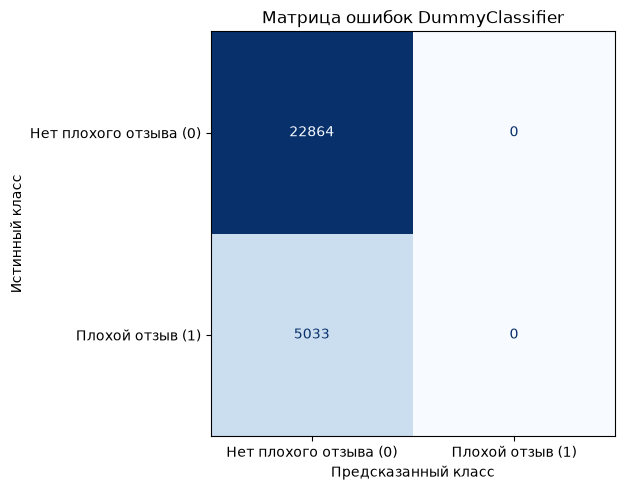

In [34]:
#Расчёт матрицы по y_valid и dummy_valid_pred
dummy_confusion_matrix = confusion_matrix(y_true=y_valid, y_pred=dummy_valid_pred, labels=[0, 1])

#Выделение TN, FP, FN, TP
TN, FP, FN, TP = (dummy_confusion_matrix.ravel())

#Проверки размера и суммы элементов
#размер равен 2 × 2
assert dummy_confusion_matrix.shape == (2, 2)

assert (TN + FP + FN + TP) == len(y_valid)

assert (TN >= 0 and FP >= 0 and FN >= 0 and TP >= 0)

#Проверки ожидаемого поведения Dummy
assert FP == 0
assert TP == 0
assert TN == (y_valid == 0).sum()
assert FN == (y_valid == 1).sum()

#Визуализация матрицы в абсолютных значениях
fig, ax = plt.subplots(figsize=(6, 5))

display = ConfusionMatrixDisplay(
    confusion_matrix=dummy_confusion_matrix,
    display_labels=[
        "Нет плохого отзыва (0)",
        "Плохой отзыв (1)"
    ]
)

display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title("Матрица ошибок DummyClassifier")
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")

plt.tight_layout()
plt.show()


Для DummyClassifier была построена матрица ошибок на валидационной выборке. Модель отнесла все заказы к наиболее частому классу 0. Поэтому все заказы без плохого отзыва были классифицированы правильно, но все заказы с плохим отзывом были пропущены. Значения False Positive и True Positive равны нулю, а количество False Negative совпадает с числом плохих отзывов в validation. Несмотря на сравнительно высокую общую долю правильных ответов, DummyClassifier не обнаруживает ни одного рискованного заказа и не решает поставленную задачу. Полученная матрица будет использоваться как минимальный ориентир для сравнения с логистической регрессией. Тестовая выборка не использовалась.

## 6.15. Метрики классификации

In [35]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

dummy_accuracy = accuracy_score(y_valid, dummy_valid_pred)
dummy_precision = precision_score(y_true=y_valid, y_pred=dummy_valid_pred, zero_division=0)
dummy_recall = recall_score(y_valid, dummy_valid_pred)
dummy_f1 = f1_score(y_true=y_valid, y_pred=dummy_valid_pred, zero_division=0)
dummy_roc_auc = roc_auc_score(y_valid, dummy_valid_proba_positive)
dummy_average_precision = average_precision_score(y_valid, dummy_valid_proba_positive)

dummy_metrics = pd.DataFrame(
    {
        "metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "Average Precision"
        ],
        "value": [
            dummy_accuracy,
            dummy_precision,
            dummy_recall,
            dummy_f1,
            dummy_roc_auc,
            dummy_average_precision
        ]
    }
)

dummy_metrics.style.format({"value": "{:.4f}"})

,metric,value
0,Accuracy,0.8196
1,Precision,0.0000
2,Recall,0.0000
3,F1,0.0000
4,ROC-AUC,0.5000
5,Average Precision,0.1804


In [36]:
# проверки
import math

#все метрики находятся между 0 и 1
assert dummy_metrics["value"].between(0, 1).all()

#accuracy соответствует доле класса 0 в validation
assert math.isclose(dummy_accuracy, ((y_valid == 0).sum() / len(y_valid)))

#precision, recall и F1 равны нулю
assert dummy_precision == 0
assert dummy_recall == 0
assert dummy_f1 == 0

#ROC-AUC примерно равна 0.5
assert math.isclose(dummy_roc_auc, 0.5)

#Average Precision примерно совпадает с долей класса 1 в validation
assert math.isclose(dummy_average_precision, y_valid.mean())

DummyClassifier показывает сравнительно высокую accuracy только потому, что большинство заказов относится к классу 0. При этом precision, recall и F1 равны нулю: модель не выявила ни одного заказа с будущим плохим отзывом. ROC-AUC, равная 0.5, указывает на отсутствие способности ранжировать заказы по риску. Average Precision приблизительно совпадает с долей плохих отзывов в validation, что соответствует неинформативному baseline. Поэтому accuracy не подходит в качестве основной метрики, а основным ориентиром для сравнения следующих моделей будет Average Precision.

## 6.16. Функция оценки модели

In [37]:
def evalute_classifier(y_true, y_pred, y_proba_positive, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba_positive)
    average_precision = average_precision_score(y_true, y_proba_positive)

    confusion_matrix_result = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(6, 5))

    display = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix_result,
        display_labels=[
            "Нет плохого отзыва (0)",
            "Плохой отзыв (1)"
        ]
    )

    display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    ax.set_title(f"Матрица ошибок {model_name}")
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")

    plt.tight_layout()
    plt.show()

    metrics = pd.DataFrame(
        {
            "model": [model_name] * 6,

            "metric": [
                "Accuracy",
                "Precision",
                "Recall",
                "F1",
                "ROC-AUC",
                "Average Precision"
            ],
            "value": [
                accuracy,
                precision,
                recall,
                f1,
                roc_auc,
                average_precision
            ]
        }
    )

    return metrics

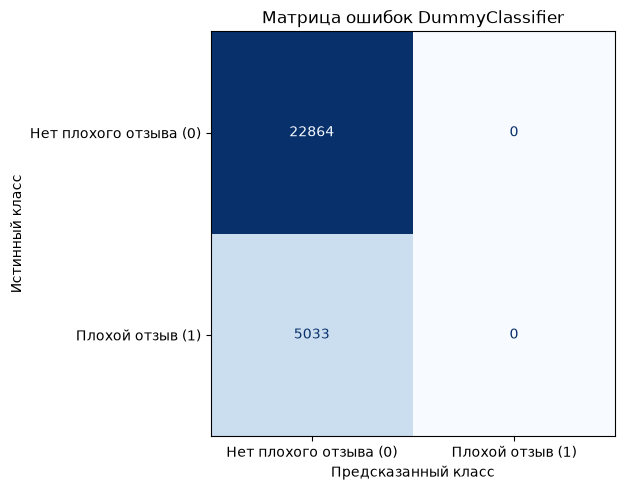

In [38]:
#проверка на dummy
dummy_metrics = evalute_classifier(y_valid, dummy_valid_pred, dummy_valid_proba_positive, "DummyClassifier")

In [39]:
dummy_metrics

,model,metric,value
0,DummyClassifier,Accuracy,0.819586
1,DummyClassifier,Precision,0.000000
2,DummyClassifier,Recall,0.000000
3,DummyClassifier,F1,0.000000
4,DummyClassifier,ROC-AUC,0.500000
5,DummyClassifier,Average Precision,0.180414


## 6.17. Логистическая регрессия

In [40]:
#Шаг 1. Создать классификатор
logistic_regression= LogisticRegression(max_iter=1000)

#Шаг 2. Создать независимый preprocessor
logistic_regression_preprocessor = clone(preprocessor)

#Шаг 3. Создать полный pipeline
logistic_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", logistic_regression_preprocessor),
        ("classifier", logistic_regression)
    ]
)

#Шаг 4. Обучить pipeline
logistic_regression_pipeline.fit(X_train, y_train)

#Шаг 5. Получить классы на validation
logistic_regression_valid_pred = logistic_regression_pipeline.predict(X_valid)

#Шаг 6. Получить вероятности на validation
logistic_regression_valid_proba = logistic_regression_pipeline.predict_proba(X_valid)

# проверка: порядок классов
logistic_regression_classes = logistic_regression_pipeline.named_steps["classifier"].classes_
assert np.array_equal(logistic_regression_classes, np.array([0, 1]))

#Выделение вероятностей класса 1
logistic_regression_valid_proba_positive = logistic_regression_valid_proba[:, 1]


In [41]:
#Шаг 7. Провести технические проверки

#длина массива прогнозов равна длине y_valid
assert len(logistic_regression_valid_pred) == len(y_valid)

#длина массива вероятностей равна длине y_valid
assert len(logistic_regression_valid_proba_positive) == len(y_valid)

#прогнозы содержат только 0 и 1
assert set(np.unique(logistic_regression_valid_pred)).issubset({0, 1})

#все вероятности находятся между 0 и 1
assert np.all((logistic_regression_valid_proba_positive >= 0) & (logistic_regression_valid_proba_positive <= 1))

#вероятности не одинаковы для всех заказов
assert len(np.unique(logistic_regression_valid_proba_positive)) > 1


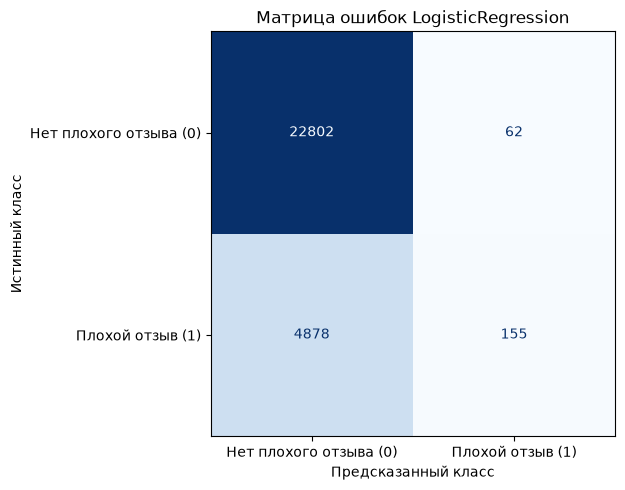

In [42]:
logistic_regression_metrics = evalute_classifier(y_valid, logistic_regression_valid_pred, logistic_regression_valid_proba_positive, "LogisticRegression")

In [43]:
logistic_regression_metrics

,model,metric,value
0,LogisticRegression,Accuracy,0.822920
1,LogisticRegression,Precision,0.714286
2,LogisticRegression,Recall,0.030797
3,LogisticRegression,F1,0.059048
4,LogisticRegression,ROC-AUC,0.627843
5,LogisticRegression,Average Precision,0.303930


Создан единый pipeline, включающий preprocessing и логистическую регрессию. Pipeline обучен только на обучающей выборке, результаты получены на validation; тестовая выборка не использовалась. При стандартном пороге 0.5 модель характеризуется высокой точностью положительных прогнозов, но очень низкой полнотой: она обнаружила только 155 из 5033 заказов с плохим отзывом. При этом ROC-AUC и Average Precision показывают, что прогнозируемые вероятности содержат информацию для ранжирования заказов по риску. Окончательное сравнение с DummyClassifier и вывод о качестве модели будут сделаны в пункте 6.18.

## 6.18. Сравнение моделей

In [44]:
all_metrics = pd.concat([dummy_metrics, logistic_regression_metrics], ignore_index=True)
all_metrics

,model,metric,value
0,DummyClassifier,Accuracy,0.819586
1,DummyClassifier,Precision,0.000000
2,DummyClassifier,Recall,0.000000
3,DummyClassifier,F1,0.000000
4,DummyClassifier,ROC-AUC,0.500000
5,DummyClassifier,Average Precision,0.180414
6,LogisticRegression,Accuracy,0.822920
7,LogisticRegression,Precision,0.714286
8,LogisticRegression,Recall,0.030797
9,LogisticRegression,F1,0.059048


In [45]:
comparison_table = all_metrics.pivot(index="model", columns="metric", values="value")
comparison_table = comparison_table.reset_index()
comparison_table = comparison_table.rename_axis(None, axis=1)
comparison_table

,model,Accuracy,Average Precision,F1,Precision,ROC-AUC,Recall
0,DummyClassifier,0.819586,0.180414,0.000000,0.000000,0.500000,0.000000
1,LogisticRegression,0.822920,0.303930,0.059048,0.714286,0.627843,0.030797


In [46]:
metric_order = [
    "model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision"
]

comparison_table = comparison_table[metric_order]
comparison_table

,model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,DummyClassifier,0.819586,0.000000,0.000000,0.000000,0.500000,0.180414
1,LogisticRegression,0.822920,0.714286,0.030797,0.059048,0.627843,0.303930


In [47]:
comparison_table.style.format(
    {
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}"
    }
)

,model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,DummyClassifier,0.8196,0.0000,0.0000,0.0000,0.5000,0.1804
1,LogisticRegression,0.8229,0.7143,0.0308,0.0590,0.6278,0.3039


### Вывод

На валидационной выборке логистическая регрессия превзошла `DummyClassifier` по основным метрикам ранжирования. Значение **Average Precision** увеличилось с `0.1804` до `0.3039`, а **ROC-AUC** — с `0.5000` до `0.6278`. Это показывает, что признаки содержат полезную информацию, а логистическая регрессия способна ранжировать заказы по риску плохого отзыва лучше неинформативного baseline.

Accuracy изменилась незначительно: с `0.8196` до `0.8229`. Эта метрика не отражает основную проблему из-за дисбаланса классов: высокая доля правильных ответов достигается преимущественно за счёт преобладающего класса `0`.

При стандартном пороге `0.5` логистическая регрессия характеризуется высокой точностью положительных прогнозов: **precision составляет `0.7143`**. Из 217 заказов, отнесённых моделью к рискованным, 155 действительно получили плохой отзыв, а 62 оказались ложными тревогами. Однако **recall равен только `0.0308`**: модель обнаружила 155 из 5033 заказов с плохим отзывом и пропустила 4878 таких заказов. Вследствие низкого recall значение F1 также остаётся небольшим — `0.0590`.

Таким образом, логистическая регрессия является более информативной моделью по сравнению с DummyClassifier, однако стандартный порог `0.5` делает её прогнозы слишком консервативными. Модель редко назначает класс `1`, поэтому создаёт мало ложных тревог, но пропускает большинство рискованных заказов. На следующих этапах необходимо исследовать способы учёта дисбаланса классов и выбор порога классификации. Тестовая выборка при сравнении моделей не использовалась.

## 6.19. Порог классификации

In [48]:
classification_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

threshold_predictions_table = pd.DataFrame({"proba" : logistic_regression_valid_proba_positive})

# for threshold in classification_thresholds:
#     predictions = []
#     for p in logistic_regression_valid_proba_positive:
#         pred = 1 if p >= threshold else 0
#         predictions.append(pred)
#     threshold_predictions_table[threshold] = predictions

for threshold in classification_thresholds:
    predictions = (
        logistic_regression_valid_proba_positive >= threshold
    ).astype(int)
    threshold_predictions_table[threshold] = predictions

threshold_predictions_table

,proba,0.1,0.2,0.3,0.4,0.5
0,0.096097,0,0,0,0,0
1,0.092347,0,0,0,0,0
2,0.082142,0,0,0,0,0
3,0.094524,0,0,0,0,0
4,0.139806,1,0,0,0,0
...,...,...,...,...,...,...
27892,0.112013,1,0,0,0,0
27893,0.087325,0,0,0,0,0
27894,0.116805,1,0,0,0,0
27895,0.259884,1,1,0,0,0


In [49]:
threshold_metrics_table = pd.DataFrame(columns=["threshold", "predicted_positive", "TN", "FP", "FN", "TP", "precision", "recall", "F1"])

i = 0
for threshold in classification_thresholds:
    y_pred = threshold_predictions_table[threshold]

    confusion_matrix_res = confusion_matrix(y_valid, y_pred, labels=[0, 1])
    TN, FP, FN, TP = confusion_matrix_res.ravel()
    predicted_positive = TP + FP

    precision = precision_score(y_valid, y_pred, zero_division=0)
    recall = recall_score(y_valid, y_pred, zero_division=0)
    f1 = f1_score(y_valid, y_pred, zero_division=0)

    threshold_metrics_table.loc[i] = [threshold, predicted_positive, TN, FP, FN, TP, precision, recall, f1]
    i += 1


threshold_metrics_table

,threshold,predicted_positive,TN,FP,FN,TP,precision,recall,F1
0,0.1,21256.0,5832.0,17032.0,809.0,4224.0,0.198720,0.839261,0.321351
1,0.2,2217.0,21494.0,1370.0,4186.0,847.0,0.382048,0.168289,0.233655
2,0.3,749.0,22526.0,338.0,4622.0,411.0,0.548732,0.081661,0.142165
3,0.4,404.0,22709.0,155.0,4784.0,249.0,0.616337,0.049473,0.091595
4,0.5,217.0,22802.0,62.0,4878.0,155.0,0.714286,0.030797,0.059048


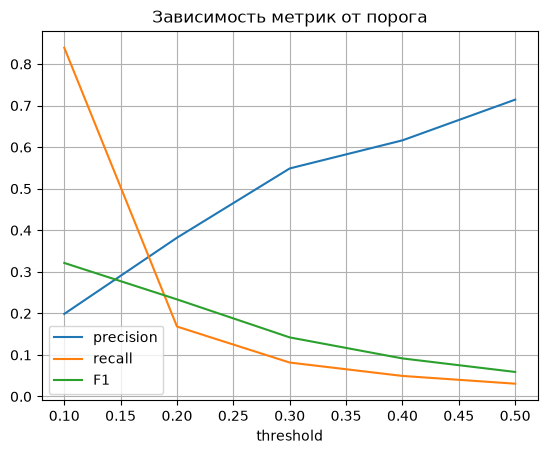

In [50]:
#график зависимости метрик от порога
plt.plot(classification_thresholds, threshold_metrics_table["precision"], label="precision")
plt.plot(classification_thresholds, threshold_metrics_table["recall"], label="recall")
plt.plot(classification_thresholds, threshold_metrics_table["F1"], label="F1")

plt.title("Зависимость метрик от порога")
plt.xlabel("threshold")

plt.legend()
plt.grid(True)
plt.show()

In [51]:
#Точный поиск через precision_recall_curve
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, exact_thresholds = precision_recall_curve(y_valid, logistic_regression_valid_proba_positive)

f1_values = np.divide(
    2 * precision_values[:-1] * recall_values[:-1],
    precision_values[:-1] + recall_values[:-1],
    out=np.zeros_like(exact_thresholds),
    where=(precision_values[:-1] + recall_values[:-1]) != 0
)

exact_threshold_metrics = pd.DataFrame(
    {
        "threshold": exact_thresholds,
        "precision": precision_values[:-1],
        "recall": recall_values[:-1],
        "F1": f1_values
    }
)

exact_threshold_metrics

,threshold,precision,recall,F1
0,0.028509,0.180414,1.000000,0.305679
1,0.037015,0.180384,0.999801,0.305627
2,0.037506,0.180391,0.999801,0.305637
3,0.038184,0.180397,0.999801,0.305646
4,0.039020,0.180368,0.999603,0.305594
...,...,...,...,...
27891,0.936805,0.400000,0.000397,0.000794
27892,0.940461,0.500000,0.000397,0.000794
27893,0.954097,0.666667,0.000397,0.000794
27894,0.957967,0.500000,0.000199,0.000397


In [52]:
#Точный порог с максимальным F1
best_f1_index = exact_threshold_metrics["F1"].idxmax()

best_f1_result = exact_threshold_metrics.loc[best_f1_index]
best_f1_result

threshold    0.140142
precision    0.278653
recall       0.481621
F1           0.353044
Name: 19198, dtype: float64

In [53]:
#Точный порог с recall не ниже 70%
target_recall = 0.7

recall_candidates = exact_threshold_metrics.loc[exact_threshold_metrics["recall"] >= target_recall]

assert not recall_candidates.empty

target_recall_result = recall_candidates.sort_values("threshold",ascending=False).iloc[0]
target_recall_result

threshold    0.112760
precision    0.222615
recall       0.700179
F1           0.337823
Name: 12067, dtype: float64

In [54]:
#получение классов для выбранных порогов
best_f1_threshold = best_f1_result["threshold"]
target_recall_threshold = target_recall_result["threshold"]

best_f1_valid_pred = (logistic_regression_valid_proba_positive >= best_f1_threshold).astype(int)
target_recall_valid_pred = (logistic_regression_valid_proba_positive >= target_recall_threshold).astype(int)

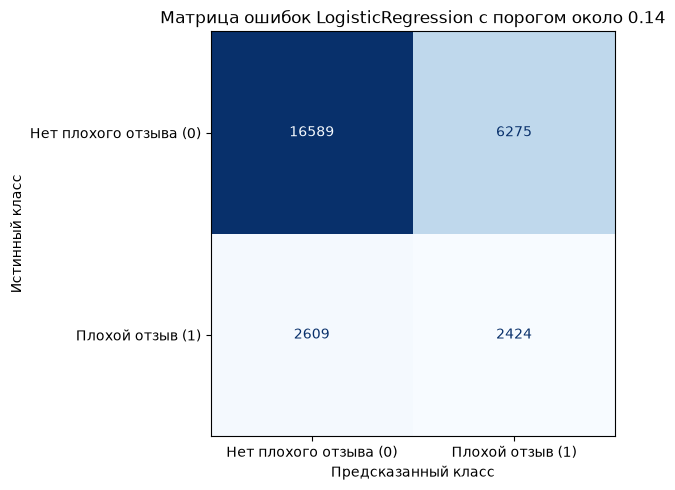

,model,metric,value
0,LogisticRegression с порогом около 0.14,Accuracy,0.681543
1,LogisticRegression с порогом около 0.14,Precision,0.278653
2,LogisticRegression с порогом около 0.14,Recall,0.481621
3,LogisticRegression с порогом около 0.14,F1,0.353044
4,LogisticRegression с порогом около 0.14,ROC-AUC,0.627843
5,LogisticRegression с порогом около 0.14,Average Precision,0.303930


In [55]:
best_f1_threshold_metrics = evalute_classifier(y_valid, best_f1_valid_pred, logistic_regression_valid_proba_positive, "LogisticRegression с порогом около 0.14")
best_f1_threshold_metrics

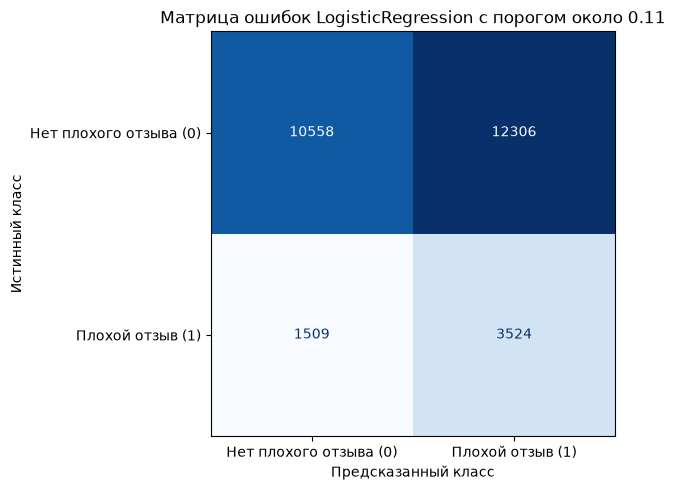

,model,metric,value
0,LogisticRegression с порогом около 0.11,Accuracy,0.504785
1,LogisticRegression с порогом около 0.11,Precision,0.222615
2,LogisticRegression с порогом около 0.11,Recall,0.700179
3,LogisticRegression с порогом около 0.11,F1,0.337823
4,LogisticRegression с порогом около 0.11,ROC-AUC,0.627843
5,LogisticRegression с порогом около 0.11,Average Precision,0.303930


In [56]:
target_recall_threshold_metrics = evalute_classifier(y_valid, target_recall_valid_pred, logistic_regression_valid_proba_positive, "LogisticRegression с порогом около 0.11")
target_recall_threshold_metrics

In [57]:
#проверки

assert 0 <= best_f1_threshold <= 1
assert 0 <= target_recall_threshold <= 1

assert target_recall_result["recall"] >= target_recall

assert (
    best_f1_result["F1"]
    >= threshold_metrics_table["F1"].max()
)

### Вывод

Исследование грубой сетки порогов показало существенную зависимость результатов классификации от выбранного порога. При стандартном пороге `0.5` модель обнаруживала только около `3.1%` заказов с будущим плохим отзывом. Снижение порога увеличивало recall, но одновременно приводило к росту числа ложных тревог и снижению precision.

Грубая сетка с шагом `0.1` оказалась недостаточно точной: максимальное значение F1 среди проверенных вариантов наблюдалось на границе сетки при пороге `0.1` и составляло `0.3214`. Поэтому был проведён точный поиск по всем уникальным значениям вероятностей на валидационной выборке.

Максимальное значение F1, равное `0.3530`, получено при пороге приблизительно `0.1401`. При этом модель обнаруживает `48.2%` заказов с плохим отзывом, а precision составляет `27.9%`. Модель правильно выявляет 2424 проблемных заказа, пропускает 2609 таких заказов и создаёт 6275 ложных предупреждений. Этот порог представляет учебный компромисс между precision и recall.

Второй кандидат выбирался по условию `recall ≥ 70%`. Наибольший порог, удовлетворяющий этому требованию, составил приблизительно `0.1128`. При нём recall равен `70.0%`, precision — `22.3%`, а F1 — `0.3378`. Модель обнаруживает 3524 заказа с плохим отзывом и пропускает 1509, но при этом создаёт 12 306 ложных предупреждений. Таким образом, увеличение полноты обнаружения достигается ценой существенного роста нагрузки, связанной с ложными тревогами.

ROC-AUC и Average Precision для обоих порогов остаются неизменными и равны соответственно `0.6278` и `0.3039`, поскольку эти метрики рассчитываются по вероятностям и не зависят от выбранного порога классификации.

Оба найденных порога являются учебными кандидатами, а не окончательным бизнес-решением. Порог максимального F1 обеспечивает более сбалансированное соотношение precision и recall, тогда как порог с целевым recall ориентирован на обнаружение большей доли рискованных заказов. Для окончательного выбора необходимо знать допустимое количество предупреждений и относительную стоимость ложной тревоги и пропущенного плохого отзыва. Все пороги подбирались только на validation; тестовая выборка не использовалась.

## 6.20. Precision-Recall curve

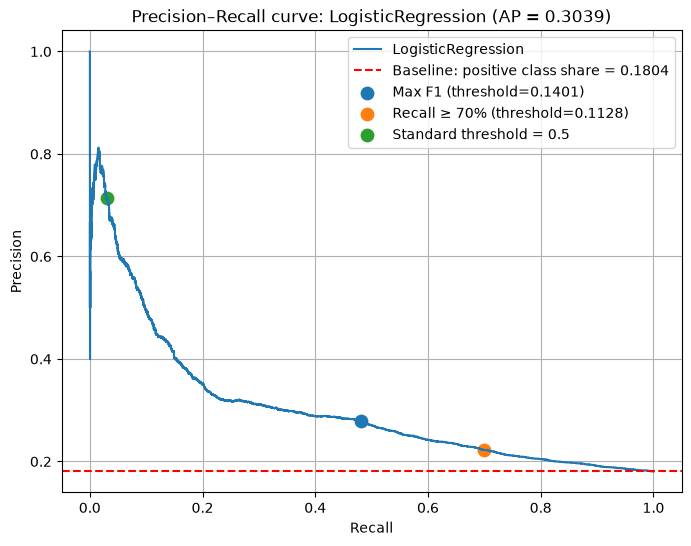

In [58]:
baseline = y_valid.mean()

plt.figure(figsize=(8, 6))

plt.step(
    recall_values,
    precision_values,
    where="post",
    label="LogisticRegression"
)

plt.axhline(y=baseline, label=f"Baseline: positive class share = {baseline:.4f}", color="red", linestyle='--')

plt.scatter(
    best_f1_result["recall"],
    best_f1_result["precision"],
    s=80,
    label=(
        f"Max F1 "
        f"(threshold={best_f1_result['threshold']:.4f})"
    )
)

plt.scatter(
    target_recall_result["recall"],
    target_recall_result["precision"],
    s=80,
    label=(
        f"Recall ≥ 70% "
        f"(threshold={target_recall_result['threshold']:.4f})"
    )
)

plt.scatter(
    logistic_regression_metrics.loc[logistic_regression_metrics["metric"] == "Recall", "value"].iloc[0],
    logistic_regression_metrics.loc[logistic_regression_metrics["metric"] == "Precision", "value"].iloc[0],
    s=80,
    label="Standard threshold = 0.5"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall curve: LogisticRegression (AP = {logistic_regression_metrics.loc[logistic_regression_metrics["metric"] == "Average Precision", "value"].iloc[0]:.4f})")
plt.grid()
plt.legend()

plt.show()

### Вывод

На валидационной выборке построена Precision–Recall-кривая логистической регрессии. Горизонтальная baseline-линия соответствует доле заказов с плохим отзывом в validation и составляет приблизительно `0.1804`. Большая часть PR-кривой располагается выше этого уровня, а Average Precision равна `0.3039`. Следовательно, модель ранжирует заказы по риску плохого отзыва лучше неинформативного случайного отбора.

PR-кривая наглядно показывает компромисс между precision и recall. При стандартном пороге `0.5` precision достигает примерно `0.7143`, однако recall составляет лишь `0.0308`. Таким образом, предупреждения модели достаточно точны, но она обнаруживает только около 3% всех заказов с плохим отзывом.

Порог максимального F1, равный приблизительно `0.1401`, обеспечивает более сбалансированный режим: precision составляет `0.2787`, recall — `0.4816`, F1 — `0.3530`. При этом модель обнаруживает около 48% будущих плохих отзывов.

При пороге около `0.1128`, выбранном по условию `recall ≥ 70%`, recall достигает `0.7002`, а precision снижается до `0.2226`. Этот режим позволяет обнаружить больше проблемных заказов, но сопровождается существенным увеличением числа ложных предупреждений.

Таким образом, стандартный порог `0.5` не подходит для задачи, если важно обнаруживать значительную долю рискованных заказов. Порог максимального F1 представляет учебный сбалансированный вариант, а порог целевого recall ориентирован на сокращение числа пропущенных плохих отзывов. Окончательный рабочий порог нельзя определить без информации о допустимом количестве ложных тревог и стоимости разных видов ошибок. Все результаты и пороги получены только на validation; тестовая выборка не использовалась.

## 6.21. Logistic Regression Balanced

In [59]:
#Шаг 1. Создать классификатор
logistic_regression_balanced= LogisticRegression(max_iter=1000, class_weight="balanced")

#Шаг 2. Создать независимый preprocessor
logistic_regression_balanced_preprocessor = clone(preprocessor)

#Шаг 3. Создать полный pipeline
logistic_regression_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", logistic_regression_balanced_preprocessor),
        ("classifier", logistic_regression_balanced)
    ]
)

#Шаг 4. Обучить pipeline
logistic_regression_balanced_pipeline.fit(X_train, y_train)

#Шаг 5. Получить классы на validation
logistic_regression_balanced_valid_pred = logistic_regression_balanced_pipeline.predict(X_valid)

#Шаг 6. Получить вероятности на validation
logistic_regression_balanced_valid_proba = logistic_regression_balanced_pipeline.predict_proba(X_valid)

# проверка: порядок классов
logistic_regression_balanced_classes = logistic_regression_balanced_pipeline.named_steps["classifier"].classes_
assert np.array_equal(logistic_regression_balanced_classes, np.array([0, 1]))

#Выделение вероятностей класса 1
logistic_regression_balanced_valid_proba_positive = logistic_regression_balanced_valid_proba[:, 1]

In [60]:
#Шаг 7. Провести технические проверки

#длина массива прогнозов равна длине y_valid
assert len(logistic_regression_balanced_valid_pred) == len(y_valid)

#длина массива вероятностей равна длине y_valid
assert len(logistic_regression_balanced_valid_proba_positive) == len(y_valid)

#прогнозы содержат только 0 и 1
assert set(np.unique(logistic_regression_balanced_valid_pred)).issubset({0, 1})

#все вероятности находятся между 0 и 1
assert np.all((logistic_regression_balanced_valid_proba_positive >= 0) & (logistic_regression_balanced_valid_proba_positive <= 1))

#вероятности не одинаковы для всех заказов
assert len(np.unique(logistic_regression_balanced_valid_proba_positive)) > 1

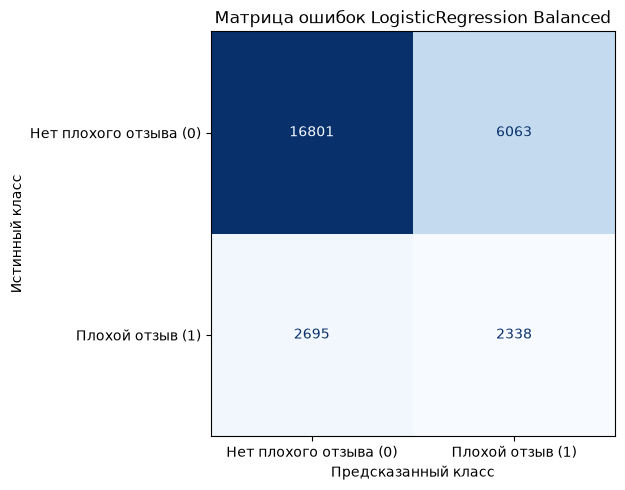

,model,metric,value
0,LogisticRegression Balanced,Accuracy,0.686059
1,LogisticRegression Balanced,Precision,0.278300
2,LogisticRegression Balanced,Recall,0.464534
3,LogisticRegression Balanced,F1,0.348072
4,LogisticRegression Balanced,ROC-AUC,0.626805
5,LogisticRegression Balanced,Average Precision,0.302985


In [61]:
logistic_regression_balanced_metrics = evalute_classifier(y_valid, logistic_regression_balanced_valid_pred, logistic_regression_balanced_valid_proba_positive, "LogisticRegression Balanced")
logistic_regression_balanced_metrics

In [62]:
all_metrics = pd.concat([all_metrics, logistic_regression_balanced_metrics, best_f1_threshold_metrics, target_recall_threshold_metrics], ignore_index=True)
all_metrics

,model,metric,value
0,DummyClassifier,Accuracy,0.819586
1,DummyClassifier,Precision,0.000000
2,DummyClassifier,Recall,0.000000
3,DummyClassifier,F1,0.000000
4,DummyClassifier,ROC-AUC,0.500000
5,DummyClassifier,Average Precision,0.180414
6,LogisticRegression,Accuracy,0.822920
7,LogisticRegression,Precision,0.714286
8,LogisticRegression,Recall,0.030797
9,LogisticRegression,F1,0.059048


In [63]:
comparison_table = all_metrics.pivot(index="model", columns="metric", values="value")
comparison_table = comparison_table.reset_index()
comparison_table = comparison_table.rename_axis(None, axis=1)
comparison_table = comparison_table[metric_order]
comparison_table

,model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,DummyClassifier,0.819586,0.000000,0.000000,0.000000,0.500000,0.180414
1,LogisticRegression,0.822920,0.714286,0.030797,0.059048,0.627843,0.303930
2,LogisticRegression Balanced,0.686059,0.278300,0.464534,0.348072,0.626805,0.302985
3,LogisticRegression с порогом около 0.11,0.504785,0.222615,0.700179,0.337823,0.627843,0.303930
4,LogisticRegression с порогом около 0.14,0.681543,0.278653,0.481621,0.353044,0.627843,0.303930


### Вывод

Использование `class_weight="balanced"` заметно изменило поведение логистической регрессии при стандартном пороге 0.5. Recall вырос с 0.031 до 0.465, поэтому модель стала обнаруживать значительно больше заказов с будущим плохим отзывом: число истинно положительных прогнозов увеличилось со 155 до 2338. Одновременно precision снизился с 0.714 до 0.278, а количество ложных тревог выросло с 62 до 6063. В результате accuracy уменьшилась с 0.823 до 0.686, но F1 выросла с 0.059 до 0.348.

При этом качество ранжирования практически не изменилось: ROC-AUC составил 0.627 против 0.628 у обычной логистической регрессии, а Average Precision — 0.303 против 0.304. Следовательно, взвешивание классов не улучшило способность модели отделять проблемные заказы от остальных, а главным образом изменило распределение прогнозируемых вероятностей и поведение модели при стандартном пороге.

Результат сбалансированной модели также оказался близок к результату обычной логистической регрессии с подобранным порогом около 0.14. У обычной модели при этом пороге получены немного более высокие recall (0.482 против 0.465) и F1 (0.353 против 0.348) при практически одинаковом precision (0.279 и 0.278).

Таким образом, `class_weight="balanced"` действительно помогает стандартному классификатору находить больше объектов редкого класса, но не даёт преимущества перед настройкой порога обычной логистической регрессии. Для дальнейших экспериментов разумно оставить обычную модель и выбирать её порог в соответствии с необходимым соотношением между recall и количеством ложных тревог. Окончательный порог должен определяться с учётом бизнес-стоимости ошибок, поэтому полученные варианты пока следует считать учебными кандидатами, выбранными только по validation.

## 6.22. Проверка переобучения

In [64]:
#Получить прогнозы модели на X_train
logistic_regression_train_pred = logistic_regression_pipeline.predict(X_train)
logistic_regression_train_proba = logistic_regression_pipeline.predict_proba(X_train)

# проверка: порядок классов
logistic_regression_classes = logistic_regression_pipeline.named_steps["classifier"].classes_
assert np.array_equal(logistic_regression_classes, np.array([0, 1]))

logistic_regression_train_proba_positive = logistic_regression_train_proba[:, 1]

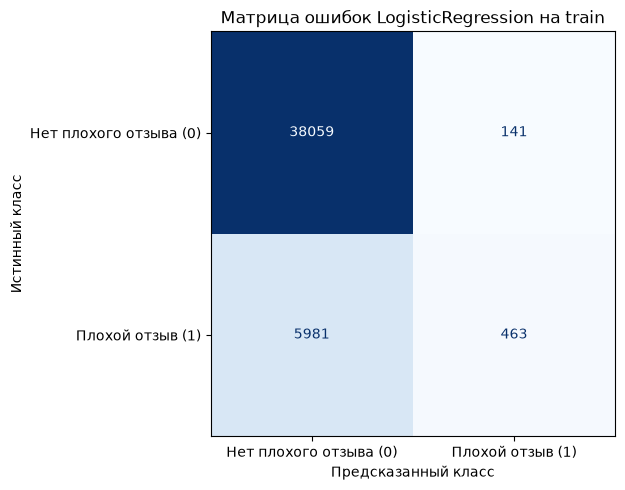

,model,metric,value
0,LogisticRegression на train,Accuracy,0.862871
1,LogisticRegression на train,Precision,0.766556
2,LogisticRegression на train,Recall,0.071850
3,LogisticRegression на train,F1,0.131385
4,LogisticRegression на train,ROC-AUC,0.647318
5,LogisticRegression на train,Average Precision,0.305342


In [65]:
logistic_regression_train_metrics = evalute_classifier(y_train, logistic_regression_train_pred, logistic_regression_train_proba_positive, "LogisticRegression на train")
logistic_regression_train_metrics

In [66]:
all_metrics = pd.concat([logistic_regression_metrics, logistic_regression_train_metrics], ignore_index=True)
all_metrics

,model,metric,value
0,LogisticRegression,Accuracy,0.822920
1,LogisticRegression,Precision,0.714286
2,LogisticRegression,Recall,0.030797
3,LogisticRegression,F1,0.059048
4,LogisticRegression,ROC-AUC,0.627843
5,LogisticRegression,Average Precision,0.303930
6,LogisticRegression на train,Accuracy,0.862871
7,LogisticRegression на train,Precision,0.766556
8,LogisticRegression на train,Recall,0.071850
9,LogisticRegression на train,F1,0.131385


In [67]:
comparison_table = all_metrics.pivot(index="model", columns="metric", values="value")
comparison_table = comparison_table.reset_index()
comparison_table = comparison_table.rename_axis(None, axis=1)
comparison_table = comparison_table[metric_order]
comparison_table

,model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,LogisticRegression,0.822920,0.714286,0.030797,0.059048,0.627843,0.303930
1,LogisticRegression на train,0.862871,0.766556,0.071850,0.131385,0.647318,0.305342


### Вывод

Результаты логистической регрессии на обучающей и валидационной выборках достаточно близки. ROC-AUC снизился с 0.647 на train до 0.628 на validation, то есть разница составляет около 0.02. Average Precision практически не изменился: 0.305 на train и 0.304 на validation. Это говорит о том, что выраженных признаков переобучения нет: способность модели ранжировать заказы сохраняется на данных более позднего периода.

При стандартном пороге 0.5 различия заметнее. На train получены recall 0.072 и F1 0.131, тогда как на validation — recall 0.031 и F1 0.059. Однако эти показатели зависят не только от качества ранжирования, но и от выбранного порога, распределения вероятностей и доли плохих отзывов в каждом временном периоде. Поэтому их снижение не следует автоматически считать доказательством переобучения.

В целом модель обобщает результаты достаточно стабильно, но её качество остаётся умеренным: ROC-AUC находится около 0.63–0.65, а при стандартном пороге модель пропускает большую часть плохих отзывов. Следовательно, основное ограничение связано скорее с невысокой разделяющей способностью текущих признаков и неудачным для данной задачи порогом 0.5, а не с запоминанием обучающих данных. Для повышения качества в следующих экспериментах необходимо исследовать более информативные признаки, другие модели и настройку гиперпараметров, а порог классификации выбирать отдельно на validation с учётом бизнес-цели.

## 6.23. Проверка качества по временным периодам

In [68]:
validation_period_analysis = pd.DataFrame({"month": X_valid["purchase_month"], "y_true": y_valid, "y_proba": logistic_regression_valid_proba_positive})

#проверки
#число дат равно длине y_valid
assert len(X_valid["purchase_month"]) == len(y_valid)

#длина y_valid равна длине массива вероятностей
assert len(y_valid) == len(logistic_regression_valid_proba_positive)

#отсутствуют пропуски в месяце, целевом признаке и вероятности
assert validation_period_analysis["month"].isna().sum() == 0
assert validation_period_analysis["y_true"].isna().sum() == 0
assert validation_period_analysis["y_proba"].isna().sum() == 0

#вероятности находятся от 0 до 1
assert np.all((logistic_regression_valid_proba_positive >= 0) & (logistic_regression_valid_proba_positive <= 1))

#в таблице остались только месяцы с января по апрель 2018 года
assert validation_period_analysis["month"].between(1, 4).all()


In [69]:
validation_period_metrics = validation_period_analysis.groupby("month").agg(
    orders_count=("y_true", "size"),
    bad_reviews_count=("y_true", "sum"),
    bad_review_share=("y_true", "mean"),
    mean_predicted_probability=("y_proba", "mean")
)

validation_period_metrics["Average Precision"] = (validation_period_analysis.groupby("month")[["y_true", "y_proba"]]
                                                  .apply(lambda month_data: average_precision_score(month_data["y_true"], month_data["y_proba"])))

validation_period_metrics["ROC-AUC"] = (validation_period_analysis.groupby("month")[["y_true", "y_proba"]]
                                                  .apply(lambda month_data: roc_auc_score(month_data["y_true"], month_data["y_proba"])))

validation_period_metrics = validation_period_metrics.round({
    "bad_review_share": 4,
    "Average Precision": 4,
    "ROC-AUC": 4,
    "mean_predicted_probability": 4
})

validation_period_metrics

,orders_count,bad_reviews_count,bad_review_share,mean_predicted_probability,Average Precision,ROC-AUC
month,,,,,,
1,7200,1116,0.1550,0.1325,0.3326,0.6604
2,6669,1394,0.2090,0.1371,0.3403,0.6291
3,7145,1629,0.2280,0.1312,0.3427,0.6292
4,6883,894,0.1299,0.1483,0.2410,0.6370


In [70]:
#проверки

#сумма orders_count равна числу объектов в y_valid
assert validation_period_metrics["orders_count"].sum() == len(y_valid)

#сумма bad_reviews_count равна общему числу единиц в y_valid
assert validation_period_metrics["bad_reviews_count"].sum() == y_valid.sum()

#все доли и метрики находятся от 0 до 1
assert validation_period_metrics["bad_review_share"].between(0, 1).all()
assert validation_period_metrics["mean_predicted_probability"].between(0, 1).all()
assert validation_period_metrics["Average Precision"].between(0, 1).all()
assert validation_period_metrics["ROC-AUC"].between(0, 1).all()

#количество заказов в каждом месяце больше нуля
assert (validation_period_metrics["orders_count"] > 0).all()


### Вывод

Качество ранжирования модели по месяцам validation-периода остаётся относительно стабильным. ROC-AUC изменяется от 0.629 до 0.660: наилучший результат получен в январе, а наиболее низкий — в феврале и марте. Разница между месяцами невелика, поэтому выраженного резкого ухудшения способности модели разделять хорошие и проблемные заказы не наблюдается.

Average Precision во всех месяцах превышает соответствующую долю плохих отзывов, которая служит месячным baseline для этой метрики. Следовательно, модель во всех четырёх периодах ранжирует заказы лучше случайного классификатора. Самое высокое абсолютное значение Average Precision получено в марте — 0.343, а самое низкое в апреле — 0.241. Однако напрямую сравнивать эти значения без учёта доли положительного класса нельзя: в марте доля плохих отзывов составляла 22.8%, тогда как в апреле — только 13.0%.

Наиболее заметная временная нестабильность наблюдается не в качестве ранжирования, а в соответствии прогнозируемого и фактического уровня риска. В январе модель предсказывала в среднем вероятность плохого отзыва 13.3% при фактической доле 15.5%. В феврале и марте модель существенно недооценивала риск: средние вероятности составили 13.7% и 13.1% при фактических долях 20.9% и 22.8%. В апреле ситуация изменилась: модель, наоборот, немного переоценила риск — 14.8% против фактических 13.0%.

Таким образом, модель достаточно стабильно ранжирует заказы в разные месяцы, но её вероятности не полностью учитывают изменение частоты плохих отзывов во времени. Особенно сильное недооценивание риска наблюдается в феврале и марте. Это указывает на изменение распределения целевого признака и возможное ухудшение калибровки модели во времени. При дальнейшем развитии проекта следует контролировать не только ROC-AUC и Average Precision, но и соответствие средних прогнозируемых вероятностей фактической доле плохих отзывов.

## 6.24. Анализ ошибок логистической регрессии на validation при пороге 0.14

In [71]:
# Проверяем, что таблицы относятся к одним и тем же заказам
assert len(metadata_valid) == len(y_valid)
assert len(metadata_valid) == len(logistic_regression_valid_proba_positive)

assert metadata_valid.index.equals(X_valid.index)
assert metadata_valid.index.equals(y_valid.index)

# Точный порог, ранее выбранный по максимальному F1
selected_threshold = best_f1_threshold

# Получаем классы при выбранном пороге
selected_valid_pred = (logistic_regression_valid_proba_positive >= selected_threshold).astype(int)

# Создаём единую таблицу для анализа ошибок
validation_error_analysis = metadata_valid.copy()

validation_error_analysis["y_true"] = y_valid.to_numpy()
validation_error_analysis["y_proba"] = logistic_regression_valid_proba_positive
validation_error_analysis["y_pred"] = selected_valid_pred

validation_error_analysis

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,y_true,y_proba,y_pred
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,0,0.096097,0
14,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,04cf8185c71090d28baa4407b2e6d600,2018-03-01 14:14:28,0,0.092347,0
20,f848643eec1d69395095eb3840d2051e,4fa1cd166fa598be6de80fa84eaade43,68954feaafe4dd638f3bd3e2afa174ec,2018-03-15 08:52:40,0,0.082142,0
21,2807d0e504d6d4894d41672727bc139f,72ae281627a6102d9b3718528b420f8a,b8df986511d928829c3192c2ed081eba,2018-02-03 20:37:35,0,0.094524,0
22,95266dbfb7e20354baba07964dac78d5,a166da34890074091a942054b36e4265,451e48381edab7f1f6dbfa6d728616ff,2018-01-08 07:55:29,0,0.139806,0
...,...,...,...,...,...,...,...
98183,d692ef54145c9cb3322ec2e5508aa3f4,82ddfcf9438b0cd1117b55ac33184df8,397cd1affbb66fa8f76e8ac24685440a,2018-03-21 19:47:18,1,0.112013,0
98188,c81f74e50f0496fa39716cc77cacd460,7b270ebc87c25c8404348c10ff80a80e,324a22205906aa2612a33e63c00ca8bb,2018-03-04 22:48:38,0,0.087325,0
98195,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,da62f9e57a76d978d02ab5362c509660,2018-02-06 12:58:58,0,0.116805,0
98197,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,2018-01-08 21:28:27,1,0.259884,1


In [72]:
assert len(validation_error_analysis) == len(y_valid)

assert validation_error_analysis["order_id"].is_unique

assert validation_error_analysis[
    ["y_true", "y_proba", "y_pred"]
].notna().all().all()

assert validation_error_analysis["y_proba"].between(0, 1).all()

assert set(validation_error_analysis["y_true"].unique()).issubset({0, 1})
assert set(validation_error_analysis["y_pred"].unique()).issubset({0, 1})

In [73]:
#присвоить каждому заказу тип результата
def  get_error_type(row):
    if row["y_true"] == 0 and row["y_pred"] == 0:
        return "TN"

    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "FP"

    elif row["y_true"] == 1 and row["y_pred"] == 0:
        return "FN"

    elif row["y_true"] == 1 and row["y_pred"] == 1:
        return "TP"

validation_error_analysis["error_type"] = validation_error_analysis.apply(get_error_type, axis=1)

In [74]:
#количество строк каждого типа
validation_error_analysis["error_type"].value_counts()

error_type
TN    16589
FP     6275
FN     2609
TP     2424
Name: count, dtype: int64

In [75]:
#сверить с confusion matrix
TN, FP, FN, TP = confusion_matrix(validation_error_analysis["y_true"], validation_error_analysis["y_pred"]).ravel()
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 16589
FP: 6275
FN: 2609
TP: 2424


In [76]:
#Рассмотреть несколько False Positive
analysis_feature_columns = [
    "purchase_month",
    "order_total",
    "items_count",
    "sellers_count",
    "estimated_delivery_time_days",
    "approval_time_days",
    "main_payment_type",
    "customer_state"
]
validation_error_analysis = validation_error_analysis.join(
    X_valid[analysis_feature_columns],
    how="left",
    validate="one_to_one"
)

assert len(validation_error_analysis) == len(y_valid)



false_positives = validation_error_analysis.loc[validation_error_analysis["error_type"] == "FP"]
false_positives.sort_values("y_proba", ascending=False).head(10)

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,y_true,y_proba,y_pred,error_type,purchase_month,order_total,items_count,sellers_count,estimated_delivery_time_days,approval_time_days,main_payment_type,customer_state
16164,71dab1155600756af6de79de92e712e3,8c20d9bfbc96c5d39025d77a3ba83d7f,eae0a83d752b1dd32697e0e7b4221656,2018-02-01 18:32:02,0,0.957967,1,FP,2,1988.53,11.0,1.0,48.227755,0.045602,credit_card,BA
81060,7f2c22c54cbae55091a09a9653fd2b8a,f4c13379ddd0ed4f4fc1c0b49c2c5e51,fe2b2f70f3dc31c23319ae1029eac77f,2018-03-10 10:53:51,0,0.940461,1,FP,3,1048.29,11.0,2.0,24.545938,1.001447,credit_card,GO
51001,30bdf3d824d824610a49887486debcaf,d6646ea91d8cd9fc7e6882a7068779d4,efce1ab3e96ccab8b1b464326bd22417,2018-03-27 14:29:03,0,0.936805,1,FP,3,785.24,10.0,3.0,27.396493,0.012963,credit_card,SP
32986,a2bcbea8668a0d93334cf7f7fafe921d,1d07a5e66ea2c0bb74e2523526326ba3,db44a2fcc338d9b3d22dda89950c77fa,2018-02-12 15:38:41,0,0.907965,1,FP,2,NaN,NaN,NaN,21.348137,0.994491,credit_card,RJ
90209,637617b3ffe9e2f7a2411243829226d0,daf15f1b940cc6a72ba558f093dc00dd,37bc3d463e2a0024012a7fa587597a3c,2018-04-17 21:08:59,0,0.894632,1,FP,4,1246.95,12.0,1.0,29.118762,1.237743,boleto,SC
49943,e8fa22c3673b1dd17ea315021b1f0f61,1ff773612ab8934db89fd5afa8afe506,ef8d54b3797ea4db1d63f0ced6a906e9,2018-04-19 13:54:06,0,0.883713,1,FP,4,3018.60,10.0,1.0,32.420764,0.723067,boleto,RJ
72307,9e99d220ca1057d22b317d36cf203620,60ff6e09a676bfa797f0ae3f1282ce4d,5554446bdf14acb1a4ea581d2dcecef7,2018-01-03 17:05:21,0,0.883503,1,FP,1,NaN,NaN,NaN,28.287951,1.396100,boleto,RJ
33681,46ac809c6b319398df696f5668806fee,8059f4ffe7ad8b008c7180d4ef488528,f55f5b958b01f7040f6f42c0abaca6f4,2018-04-03 18:28:35,0,0.877985,1,FP,4,NaN,NaN,NaN,26.230150,0.014792,credit_card,GO
97620,2d57932a94a64e0729ec5b88b4860d0d,18ee349e6fe0fa105ac44232ac1f4d06,78b9dd8b77ff3abe5f5b84bc2b030d1f,2018-03-31 19:08:47,0,0.861033,1,FP,3,NaN,NaN,NaN,22.202234,2.429873,boleto,SP
6881,3a0b1b5c52367a68f9deab55f3464a14,35162935be1761d5f1fe05a66870794e,a54a1749bd03dfe0d3642b7fbd888b47,2018-03-19 16:22:05,0,0.858715,1,FP,3,NaN,NaN,NaN,51.317998,0.046944,credit_card,SC


In [77]:
#Рассмотреть несколько False Negative
false_negatives = validation_error_analysis.loc[validation_error_analysis["error_type"] == "FN"]
false_negatives.sort_values("y_proba", ascending=False).head(10)

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,y_true,y_proba,y_pred,error_type,purchase_month,order_total,items_count,sellers_count,estimated_delivery_time_days,approval_time_days,main_payment_type,customer_state
1499,ad27779fb29796c8d798f29aefedf3d0,aceb1218ab19cb199ebe711d613f9fae,4578c59d3730444c9221fb635f7af881,2018-04-05 11:39:33,1,0.140049,0,FN,4,119.74,1.0,1.0,21.514201,0.010972,credit_card,CE
10802,749d73f14d7f582a7c7b12894d552da2,e265a180914056bc0152a2c2bf86721d,d108c85d2b2dc02cb296ccf1eb5974c3,2018-02-14 13:28:09,1,0.139972,0,FN,2,55.91,1.0,1.0,20.438785,0.013495,credit_card,RJ
38708,56c79c2be1ceff5839d56e340e847833,05c3177330bc9de5e895ecfe6eaf9687,f4594149af80600bda535d5b7f72a7b4,2018-04-19 01:15:00,1,0.139961,0,FN,4,119.57,1.0,1.0,24.947917,1.247407,boleto,SP
17944,ac9389991e196542581dc80f6be7e5fe,d5d2b40c4f46a961dd499fcf5541ffb8,b814324d11d2ba7ac4482460315dfb69,2018-01-01 21:11:00,1,0.139907,0,FN,1,85.23,1.0,1.0,29.117361,0.005174,credit_card,PR
80040,6d81c04e1888cf43b0ec0f83b5efe746,07ec17f4488030f86f4790f7be847ac0,eb5489a33e4263a2938cc956d91aa676,2018-03-27 17:51:13,1,0.139893,0,FN,3,132.30,1.0,1.0,19.256100,0.012488,credit_card,RJ
86340,5a8badb776e5585c274fe19201012249,ef22056dc8495090cdc55992aa9ef1a5,c1ce726cce4f19c4aef436e4b78d319d,2018-03-07 21:02:00,1,0.139822,0,FN,3,86.94,1.0,1.0,28.123611,0.005972,credit_card,CE
93296,0b88df5bf12a6df08bf27d7db86e4ab6,a3a56df70dac7a02e8717683109cef4b,bf62d5d68cc829b3e9269e7001ced2fa,2018-03-31 09:01:18,1,0.139819,0,FN,3,60.05,1.0,1.0,26.624097,0.009618,credit_card,BA
73574,f07ffa8133ca1dcbc015a9c0ee98c872,a4eba83fdbc203894a86afba0bc15269,695bbb3da4afc645d1f16657ae1bfc9f,2018-02-13 10:15:52,1,0.139799,0,FN,2,153.41,1.0,1.0,29.572315,0.030891,credit_card,BA
53681,bac84a37ff8746de71d3ba5a6aadecdd,4966d0c89c40e0123f63d0be0ff4553f,da6ff202b1758b9ab942b03f4797a1af,2018-01-25 10:09:48,1,0.139759,0,FN,1,125.74,2.0,1.0,34.576528,0.714398,boleto,PR
49715,5af1684cbc75f2c0c5bb83e220449cdb,ffe0a690236043c15cf261a5d9fa5b5f,c0784174ca6a9ed7d56008fca100f07c,2018-01-03 08:15:46,1,0.139730,0,FN,1,151.60,1.0,1.0,32.655718,0.008102,credit_card,RJ


In [78]:
#Сравнить группы FN и TP
numeric_analysis_columns = [
    "order_total",
    "items_count",
    "sellers_count",
    "estimated_delivery_time_days"
]

fn_tp_numeric_comparison = (
    validation_error_analysis
    .loc[
        validation_error_analysis["error_type"].isin(["FN", "TP"])
    ]
    .groupby("error_type")[numeric_analysis_columns]
    .agg(["median", "mean"])
)

fn_tp_numeric_comparison


order_total             items_count           sellers_count  \
                median        mean      median      mean        median   
error_type                                                               
FN               98.34  140.886619         1.0  1.041395           1.0   
TP              157.36  237.637416         1.0  1.580948           1.0   

                    estimated_delivery_time_days             
               mean                       median       mean  
error_type                                                   
FN          1.00000                    22.256227  22.700108  
TP          1.09654                    26.265943  27.161510

In [79]:
#Посмотреть заказы с экстремальными вероятностями
validation_error_analysis.sort_values(by="y_proba", ascending=False).head(10)

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,y_true,y_proba,y_pred,error_type,purchase_month,order_total,items_count,sellers_count,estimated_delivery_time_days,approval_time_days,main_payment_type,customer_state
85903,1b15974a0141d54e36626dca3fdc731a,be1b70680b9f9694d8c70f41fa3dc92b,c402f431464c72e27330a67f7b94d4fb,2018-02-22 15:30:41,1,0.985646,1,TP,2,2202.40,20.0,1.0,13.353692,1.492894,boleto,SP
16164,71dab1155600756af6de79de92e712e3,8c20d9bfbc96c5d39025d77a3ba83d7f,eae0a83d752b1dd32697e0e7b4221656,2018-02-01 18:32:02,0,0.957967,1,FP,2,1988.53,11.0,1.0,48.227755,0.045602,credit_card,BA
80616,1c11d0f4353b31ac3417fbfa5f0f2a8a,50920f8cd0681fd86ebe93670c8fe52e,41a3b256cc497dc952a815b848345cbc,2018-01-27 11:28:32,1,0.954097,1,TP,1,421.70,7.0,5.0,36.521852,2.004757,voucher,RS
81060,7f2c22c54cbae55091a09a9653fd2b8a,f4c13379ddd0ed4f4fc1c0b49c2c5e51,fe2b2f70f3dc31c23319ae1029eac77f,2018-03-10 10:53:51,0,0.940461,1,FP,3,1048.29,11.0,2.0,24.545938,1.001447,credit_card,GO
51001,30bdf3d824d824610a49887486debcaf,d6646ea91d8cd9fc7e6882a7068779d4,efce1ab3e96ccab8b1b464326bd22417,2018-03-27 14:29:03,0,0.936805,1,FP,3,785.24,10.0,3.0,27.396493,0.012963,credit_card,SP
97693,62073ec6b54b8e6322037fc0f3591ad3,368f207cdc8f5c93a2b2a5d4cce96ba8,f9172a6495d46451776be8bc8e46032d,2018-04-02 12:22:06,1,0.936195,1,TP,4,1316.13,7.0,2.0,37.484653,1.338229,credit_card,RJ
85862,553fee3c21ab4328508c8e467806613e,434c715a38dc04eda3d438177d1dd98e,23c536b39a65168e3e34354b80b4ecf2,2018-01-12 23:57:07,1,0.922452,1,TP,1,NaN,NaN,NaN,48.002002,4.356690,boleto,BA
32986,a2bcbea8668a0d93334cf7f7fafe921d,1d07a5e66ea2c0bb74e2523526326ba3,db44a2fcc338d9b3d22dda89950c77fa,2018-02-12 15:38:41,0,0.907965,1,FP,2,NaN,NaN,NaN,21.348137,0.994491,credit_card,RJ
64066,eb278cfbeefc0a9180876153de58d693,e6b1fd31d830155d9a333978e90dd976,61657cd378eabeaa8ec89a448432357d,2018-02-09 19:51:24,1,0.906506,1,TP,2,NaN,NaN,NaN,23.172639,0.011574,credit_card,RJ
73361,1e792fcdefb0bb34325cdc1dee84fcea,aaed1013b9b4c5ffea9394e093564a72,4fd1dbe5a37041f5f1e8541420d03c18,2018-02-11 00:41:04,1,0.898779,1,TP,2,NaN,NaN,NaN,22.971481,0.047072,credit_card,RJ


In [80]:
validation_error_analysis.sort_values(by="y_proba").head(10)

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,y_true,y_proba,y_pred,error_type,purchase_month,order_total,items_count,sellers_count,estimated_delivery_time_days,approval_time_days,main_payment_type,customer_state
50203,c2ebe69807422446d5e8edb2060da5e9,63f9f01b26b742afbd95beb988883c52,980fb8fce0743aca3ddaaa6a1015638b,2018-03-05 03:46:04,1,0.028509,0,FN,3,200.05,1.0,1.0,42.843009,1.003380,boleto,AP
43496,a2d2cba2241c7e5f2de7e9e3ed12250b,641572a061cb58aa1e035fed93eb8ac7,3c5f20dc5a1ab7f6aea3fa985f4a53a1,2018-03-10 03:25:22,0,0.037015,0,TN,3,32.38,1.0,1.0,11.857384,0.031551,credit_card,SP
12022,0ff97226c07e92ca14cbb9d324c624a0,c8ece683fdd660e0bef8c967d4a275da,83c69c716404a358893f81c6497e6ed3,2018-03-18 03:25:48,0,0.037506,0,TN,3,73.16,1.0,1.0,22.857083,2.002118,boleto,PR
42278,9d1f77072af56fc8c0390f8e6f055a9b,abd590638fceea05312db82e077760f7,4c03eb4fe7593bf85648f9eab66670c4,2018-01-10 03:07:47,1,0.038184,0,FN,1,226.90,1.0,1.0,20.869595,0.977789,boleto,SP
22626,04b7bd5687bbcc2087d9af68fe7302b3,e25fd5064e602530991d1f6482e642f1,fd91c7c081aee2cfbc2571043f08946c,2018-03-24 03:39:41,0,0.039020,0,TN,3,92.28,1.0,1.0,18.847442,3.006829,boleto,MG
32231,a61202a33583131307321a09ff16a0fb,1a865a23a7f3bd3fff2d5557fb2a11dd,b8552e06a522be2ef1605359f3250b49,2018-03-22 03:34:22,0,0.039347,0,TN,3,72.76,1.0,1.0,18.851134,0.010405,credit_card,SP
45334,a0d1ccb35ed3e8d90bb7eecccb02ea1f,27a063840a00d5f2e10164bdf37f7a40,28537729e386e797c94fcd8447482cfd,2018-01-26 03:09:42,0,0.040141,0,TN,1,38.71,1.0,1.0,13.868264,0.006725,credit_card,SP
18410,6db6009ebbcd3dd392a0b9fdc4cec226,3136355c994d4e466d7b7fc497727e1a,3801738a5f759776df5e1ff226de8113,2018-03-05 03:46:57,0,0.040854,0,TN,3,137.37,1.0,1.0,15.842396,0.037049,credit_card,SP
79087,b5e095024706f86e26f9ae88b1d81811,fed063142605b95f0ff2fe32c641348d,0af8d59b2f4cd9169b2abc898f0e7b31,2018-01-03 03:24:57,0,0.040871,0,TN,1,82.50,1.0,1.0,22.857674,1.076678,boleto,SP
49317,6586d233be57098d348eb571d87fc6f2,8f6abc9f0ebb17ff05eceed089187832,33d32ea81f404c8700d31dccbd04ed18,2018-03-09 03:43:30,0,0.041372,0,TN,3,193.70,1.0,1.0,23.844792,0.008252,credit_card,SP


### Вывод

Анализ ошибок проведён для обычной логистической регрессии на validation при пороге около 0.14, выбранном по максимальному F1. При этом пороге модель получила 16 589 TN, 6 275 FP, 2 609 FN и 2 424 TP.

Модель обнаружила 2 424 из 5 033 заказов с плохим отзывом, то есть около 48% проблемных заказов. Одновременно она пропустила 2 609 плохих отзывов. Число ложных тревог составило 6 275 и оказалось примерно в 2.4 раза больше числа пропущенных плохих отзывов. Следовательно, снижение порога позволило заметно повысить recall, но ценой большого количества хороших заказов, ошибочно признанных рискованными.

Сравнение FN и TP показывает, что модель лучше обнаруживает более крупные и дорогие проблемные заказы. Медианная стоимость TP составила 157.36 против 98.34 у FN, а средняя — 237.64 против 140.89. Среднее количество товаров у TP равно 1.58, тогда как у FN — 1.04. Обещанный срок доставки у найденных проблемных заказов также выше: медиана составляет 26.27 дня против 22.26 дня у пропущенных.

Таким образом, модель чаще обнаруживает плохие отзывы среди заказов с высокой стоимостью, большим количеством товаров и более продолжительным обещанным сроком доставки. При этом она чаще пропускает внешне обычные заказы: сравнительно недорогие, состоящие из одного товара и оформленные у одного продавца. Вероятно, для таких заказов текущих признаков недостаточно, чтобы заранее отличить будущий плохой отзыв от хорошего.

Среди наиболее уверенных False Positive заметно присутствие крупных заказов. В наблюдениях с доступными значениями встречаются заказы стоимостью от 785 до 3 019 и с 10–12 товарами. В отдельных случаях также наблюдаются несколько продавцов или длительный обещанный срок доставки. Это показывает, что модель связывает крупный размер, высокую стоимость и сложность заказа с повышенным риском, но такие характеристики не всегда приводят к плохому отзыву. В результате модель создаёт уверенные ложные тревоги.

В части наиболее высоких прогнозируемых вероятностей 6 из 10 заказов действительно относятся к классу плохих отзывов, а 4 являются False Positive. Это значительно выше общей доли плохих отзывов в validation и подтверждает, что модель способна концентрировать проблемные заказы в верхней части рейтинга. Однако даже среди наиболее уверенных прогнозов сохраняется заметное количество ошибок.

Среди 10 заказов с минимальными вероятностями 8 являются TN, но 2 относятся к FN. Следовательно, нижняя часть рейтинга в основном состоит из действительно безопасных заказов, однако модель иногда с высокой уверенностью пропускает плохие отзывы. Эти ошибки особенно интересны: они показывают, что некоторые причины недовольства клиента не отражены в признаках, доступных модели в момент подтверждения заказа.

В нескольких наиболее уверенных прогнозах отсутствуют сведения о стоимости, количестве товаров и продавцов. Поэтому часть наблюдений нельзя полноценно интерпретировать, а влияние пропусков следует дополнительно контролировать. Также нельзя утверждать, что найденные характеристики непосредственно вызывают плохой отзыв: проведённый анализ показывает только повторяющиеся связи в прогнозах модели.

В целом модель использует осмысленные признаки риска и лучше выявляет крупные, дорогие и потенциально более сложные заказы. Основная слабость заключается в обнаружении проблем среди простых и внешне обычных заказов. В дальнейшем качество можно попытаться улучшить с помощью дополнительных признаков, описывающих состав заказа, продавца, категорию товара и особенности клиента. Полученные наблюдения пока являются направлениями для дальнейших экспериментов, а не основанием немедленно изменять модель.

## 6.25. Сохранение test закрытым

В рамках данного ноутбука обучение моделей выполнялось на train, а сравнение моделей, подбор порога классификации, проверка временной стабильности и анализ ошибок — только на validation.

Тестовая выборка не использовалась для обучения, настройки гиперпараметров, выбора признаков, выбора модели или порога классификации. Прогнозы для `X_test` не рассчитывались, а качество относительно `y_test` не оценивалось.

`X_test` и `y_test` сохранены для однократной финальной оценки после завершения всех экспериментов и фиксации окончательного pipeline и порога классификации. Такой подход позволяет получить более объективную оценку качества модели на новых данных.

## 6.26. Сохранение результатов

In [81]:
#Итоговые метрики моделей на validation
final_validation_metrics = pd.concat([dummy_metrics, logistic_regression_metrics, logistic_regression_balanced_metrics, best_f1_threshold_metrics, target_recall_threshold_metrics], ignore_index=True)

final_validation_metrics = final_validation_metrics.pivot(index="model", columns="metric", values="value")
final_validation_metrics = final_validation_metrics.reset_index()
final_validation_metrics = final_validation_metrics.rename_axis(None, axis=1)
final_validation_metrics = final_validation_metrics[metric_order]
final_validation_metrics.style.format(
    {
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}"
    }
)

,model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,DummyClassifier,0.8196,0.0000,0.0000,0.0000,0.5000,0.1804
1,LogisticRegression,0.8229,0.7143,0.0308,0.0590,0.6278,0.3039
2,LogisticRegression Balanced,0.6861,0.2783,0.4645,0.3481,0.6268,0.3030
3,LogisticRegression с порогом около 0.11,0.5048,0.2226,0.7002,0.3378,0.6278,0.3039
4,LogisticRegression с порогом около 0.14,0.6815,0.2787,0.4816,0.3530,0.6278,0.3039


In [82]:
final_validation_metrics.to_csv(
    "../data/processed/baseline_validation_metrics.csv",
    index=False
)

In [83]:
#Таблица выбранных порогов
selected_thresholds = pd.DataFrame(
    [
        {
            "selection_rule": "maximum F1",
            "threshold": best_f1_result["threshold"],
            "precision": best_f1_result["precision"],
            "recall": best_f1_result["recall"],
            "F1": best_f1_result["F1"]
        },
        {
            "selection_rule": "recall at least 0.70",
            "threshold": target_recall_result["threshold"],
            "precision": target_recall_result["precision"],
            "recall": target_recall_result["recall"],
            "F1": target_recall_result["F1"]
        }
    ]
)

selected_thresholds

,selection_rule,threshold,precision,recall,F1
0,maximum F1,0.140142,0.278653,0.481621,0.353044
1,recall at least 0.70,0.112760,0.222615,0.700179,0.337823


In [84]:
selected_thresholds.to_csv(
    "../data/processed/selected_thresholds.csv",
    index=False
)

In [85]:
#Помесячные метрики
validation_period_metrics_to_save = validation_period_metrics.reset_index()

validation_period_metrics_to_save

,month,orders_count,bad_reviews_count,bad_review_share,mean_predicted_probability,Average Precision,ROC-AUC
0,1,7200,1116,0.1550,0.1325,0.3326,0.6604
1,2,6669,1394,0.2090,0.1371,0.3403,0.6291
2,3,7145,1629,0.2280,0.1312,0.3427,0.6292
3,4,6883,894,0.1299,0.1483,0.2410,0.6370


In [86]:
validation_period_metrics_to_save.to_csv(
    "../data/processed/validation_period_metrics.csv",
    index=False
)

In [87]:
#Прогнозы на validation для анализа ошибок
validation_error_analysis

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,y_true,y_proba,y_pred,error_type,purchase_month,order_total,items_count,sellers_count,estimated_delivery_time_days,approval_time_days,main_payment_type,customer_state
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,0,0.096097,0,TN,2,28.62,1.0,1.0,12.112049,0.042940,credit_card,SP
14,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,04cf8185c71090d28baa4407b2e6d600,2018-03-01 14:14:28,0,0.092347,0,TN,3,54.36,1.0,1.0,19.406620,0.039109,credit_card,SP
20,f848643eec1d69395095eb3840d2051e,4fa1cd166fa598be6de80fa84eaade43,68954feaafe4dd638f3bd3e2afa174ec,2018-03-15 08:52:40,0,0.082142,0,TN,3,88.90,1.0,1.0,13.630093,0.011701,credit_card,SP
21,2807d0e504d6d4894d41672727bc139f,72ae281627a6102d9b3718528b420f8a,b8df986511d928829c3192c2ed081eba,2018-02-03 20:37:35,0,0.094524,0,TN,2,17.28,1.0,1.0,17.140567,0.008877,credit_card,SP
22,95266dbfb7e20354baba07964dac78d5,a166da34890074091a942054b36e4265,451e48381edab7f1f6dbfa6d728616ff,2018-01-08 07:55:29,0,0.139806,0,TN,1,187.57,1.0,1.0,43.669803,0.008356,credit_card,SC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98183,d692ef54145c9cb3322ec2e5508aa3f4,82ddfcf9438b0cd1117b55ac33184df8,397cd1affbb66fa8f76e8ac24685440a,2018-03-21 19:47:18,1,0.112013,0,FN,3,146.83,1.0,1.0,18.175486,0.012593,credit_card,SP
98188,c81f74e50f0496fa39716cc77cacd460,7b270ebc87c25c8404348c10ff80a80e,324a22205906aa2612a33e63c00ca8bb,2018-03-04 22:48:38,0,0.087325,0,TN,3,70.83,1.0,1.0,21.049560,0.014398,credit_card,MG
98195,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,da62f9e57a76d978d02ab5362c509660,2018-02-06 12:58:58,0,0.116805,0,TN,2,195.00,1.0,1.0,23.459051,0.008090,credit_card,SP
98197,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,2018-01-08 21:28:27,1,0.259884,1,TP,1,441.16,2.0,1.0,37.105243,0.005486,credit_card,RJ


In [88]:
validation_error_analysis = validation_error_analysis.drop(columns=["customer_id", "customer_unique_id"])
validation_error_analysis["classification_threshold"] = best_f1_threshold
validation_error_analysis

,order_id,order_purchase_timestamp,y_true,y_proba,y_pred,error_type,purchase_month,order_total,items_count,sellers_count,estimated_delivery_time_days,approval_time_days,main_payment_type,customer_state,classification_threshold
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,0,0.096097,0,TN,2,28.62,1.0,1.0,12.112049,0.042940,credit_card,SP,0.140142
14,432aaf21d85167c2c86ec9448c4e42cc,2018-03-01 14:14:28,0,0.092347,0,TN,3,54.36,1.0,1.0,19.406620,0.039109,credit_card,SP,0.140142
20,f848643eec1d69395095eb3840d2051e,2018-03-15 08:52:40,0,0.082142,0,TN,3,88.90,1.0,1.0,13.630093,0.011701,credit_card,SP,0.140142
21,2807d0e504d6d4894d41672727bc139f,2018-02-03 20:37:35,0,0.094524,0,TN,2,17.28,1.0,1.0,17.140567,0.008877,credit_card,SP,0.140142
22,95266dbfb7e20354baba07964dac78d5,2018-01-08 07:55:29,0,0.139806,0,TN,1,187.57,1.0,1.0,43.669803,0.008356,credit_card,SC,0.140142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98183,d692ef54145c9cb3322ec2e5508aa3f4,2018-03-21 19:47:18,1,0.112013,0,FN,3,146.83,1.0,1.0,18.175486,0.012593,credit_card,SP,0.140142
98188,c81f74e50f0496fa39716cc77cacd460,2018-03-04 22:48:38,0,0.087325,0,TN,3,70.83,1.0,1.0,21.049560,0.014398,credit_card,MG,0.140142
98195,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,0,0.116805,0,TN,2,195.00,1.0,1.0,23.459051,0.008090,credit_card,SP,0.140142
98197,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,1,0.259884,1,TP,1,441.16,2.0,1.0,37.105243,0.005486,credit_card,RJ,0.140142


In [89]:
validation_error_analysis.to_csv(
    "../data/processed/logistic_regression_validation_predictions.csv",
    index=False
)

## 6.27. Итоговый вывод ноутбука

В ноутбуке были построены и исследованы базовые модели для прогнозирования плохого отзыва по информации, доступной в момент подтверждения заказа. Обучение проводилось на train, а сравнение моделей, выбор порога и анализ ошибок — на validation. Тестовая выборка в экспериментах не использовалась.

### 1. Сравнение с Dummy baseline

Обычная логистическая регрессия превзошла DummyClassifier по способности ранжировать заказы. ROC-AUC вырос с 0.500 до 0.628, а Average Precision — с 0.180 до 0.304.

Accuracy изменилась незначительно: с 0.820 у DummyClassifier до 0.823 у логистической регрессии. Однако accuracy в этой задаче малоинформативна из-за дисбаланса классов. DummyClassifier получил высокую accuracy только потому, что относил все заказы к преобладающему классу и не обнаружил ни одного плохого отзыва: его precision, recall и F1 равны нулю.

Таким образом, логистическая регрессия действительно извлекает полезный сигнал из признаков и ранжирует заказы лучше случайного baseline.

### 2. Изменение Average Precision

Average Precision выросла с 0.180 у DummyClassifier до 0.304 у логистической регрессии. Абсолютный прирост составил приблизительно 0.124, а относительный — около 68%.

Это означает, что в верхней части списка заказов, отсортированных по прогнозируемому риску, плохие отзывы встречаются заметно чаще, чем в validation в среднем. Вместе с тем значение AP около 0.30 всё ещё указывает на умеренное качество модели и наличие значительного потенциала для улучшения.

### 3. Результаты при стандартном пороге 0.5

При пороге 0.5 логистическая регрессия получила:

- precision — 0.714;
- recall — 0.031;
- F1 — 0.059;
- accuracy — 0.823.

Из 5 033 плохих отзывов модель обнаружила только 155 и пропустила 4 878. При этом она создала только 62 ложные тревоги.

Следовательно, стандартный порог 0.5 делает модель слишком консервативной. Большинство её предупреждений правильные, но она выдаёт их крайне редко и почти не выполняет задачу поиска проблемных заказов.

### 4. Влияние снижения порога

При снижении порога модель начинает относить к классу 1 больше заказов. Recall увеличивается, но одновременно растёт количество ложных тревог и снижается precision.

При пороге около 0.140, выбранном по максимальному F1, получены:

- precision — 0.279;
- recall — 0.482;
- F1 — 0.353;
- accuracy — 0.682.

Модель обнаружила 2 424 плохих отзыва из 5 033, но сформировала 6 275 ложных предупреждений.

При пороге около 0.113, обеспечивающем recall не ниже 70%, получены:

- precision — 0.223;
- recall — 0.700;
- F1 — 0.338;
- accuracy — 0.505.

В этом случае модель обнаружила 3 524 плохих отзыва, но количество ложных тревог выросло до 12 306.

Таким образом, порог нельзя выбирать только по технической метрике. Порог около 0.14 обеспечивает наибольший F1, а порог около 0.11 подходит для сценария, в котором важнее обнаружить не менее 70% проблемных заказов. Окончательный выбор требует информации о стоимости ложной тревоги и пропущенного плохого отзыва.

Изменение порога не влияет на ROC-AUC и Average Precision, поскольку оно меняет только преобразование вероятностей в классы, но не само ранжирование заказов.

### 5. Результат применения `class_weight="balanced"`

Сбалансированная логистическая регрессия при стандартном пороге 0.5 получила:

- precision — 0.278;
- recall — 0.465;
- F1 — 0.348;
- ROC-AUC — 0.627;
- Average Precision — 0.303.

По сравнению с обычной моделью при пороге 0.5 взвешивание классов значительно повысило recall и F1. Однако качество ранжирования практически не изменилось: ROC-AUC и Average Precision остались на том же уровне.

Результат сбалансированной модели оказался очень близок к обычной логистической регрессии с порогом около 0.14. При этом обычная модель с настроенным порогом получила немного более высокие recall и F1 при практически одинаковом precision.

Следовательно, `class_weight="balanced"` изменил поведение модели при стандартном пороге, но не улучшил её способность ранжировать заказы. В данном эксперименте настройка порога обычной логистической регрессии оказалась не хуже балансировки классов.

### 6. Проверка переобучения

На train логистическая регрессия получила ROC-AUC 0.647 и Average Precision 0.305, а на validation — ROC-AUC 0.628 и Average Precision 0.304.

Разница ROC-AUC составляет около 0.02, а Average Precision практически совпадает. Поэтому выраженных признаков переобучения не обнаружено: качество модели на данных более позднего периода остаётся близким к качеству на обучающей выборке.

Более заметное различие threshold-зависимых метрик связано не только с обобщающей способностью модели, но и с изменением доли плохих отзывов и распределения вероятностей во времени. Основное ограничение модели заключается скорее в умеренной информативности признаков, чем в запоминании train.

### 7. Стабильность по месяцам

Помесячный ROC-AUC находится в диапазоне от 0.629 до 0.660. Наилучший результат получен в январе, наиболее низкий — в феврале и марте. Резкого провала качества ранжирования в отдельном месяце не наблюдается.

Average Precision изменяется от 0.241 до 0.343, но её абсолютное значение зависит от доли плохих отзывов. Во всех месяцах AP выше соответствующей месячной доли положительного класса, поэтому модель каждый месяц работает лучше случайного baseline.

При этом выявлена нестабильность прогнозируемого уровня риска. В феврале и марте модель недооценивает долю плохих отзывов:

- февраль: средняя вероятность 13.7% при фактической доле 20.9%;
- март: средняя вероятность 13.1% при фактической доле 22.8%.

В апреле модель, наоборот, немного переоценивает риск: 14.8% против фактических 13.0%.

Следовательно, ранжирование по месяцам относительно стабильно, но калибровка вероятностей меняется во времени.

### 8. Анализ ошибок

При пороге около 0.14 получены:

- TN — 16 589;
- FP — 6 275;
- FN — 2 609;
- TP — 2 424.

Модель создаёт примерно в 2.4 раза больше ложных тревог, чем пропусков плохих отзывов. При этом она всё ещё пропускает немного больше половины фактических плохих отзывов.

Сравнение FN и TP показало, что модель лучше обнаруживает более крупные и дорогие проблемные заказы. Медианная стоимость TP составляет 157.36 против 98.34 у FN. Среднее количество товаров равно 1.58 у TP и 1.04 у FN, а медианный обещанный срок доставки — 26.27 и 22.26 дня соответственно.

Таким образом, модель чаще обнаруживает риск у дорогих, крупных и потенциально более сложных заказов. Она чаще пропускает плохие отзывы среди внешне обычных заказов, состоящих из одного товара, оформленных у одного продавца и имеющих сравнительно невысокую стоимость.

Среди десяти заказов с наибольшими вероятностями шесть действительно получили плохой отзыв, а четыре оказались False Positive. В верхней части рейтинга проблемные заказы встречаются значительно чаще, чем в выборке в среднем, но даже наиболее уверенные прогнозы не всегда верны.

### 9. Ограничения baseline-модели

Основные ограничения текущего решения:

- умеренное качество ранжирования: ROC-AUC около 0.63 и AP около 0.30;
- крайне низкий recall при стандартном пороге 0.5;
- большое количество ложных тревог при снижении порога;
- отсутствие определённой бизнес-стоимости FP и FN;
- нестабильность соответствия прогнозируемого и фактического уровня риска по месяцам;
- недостаточная информативность признаков для простых и внешне обычных заказов;
- наличие пропусков в части характеристик заказов;
- исследованы только линейная модель и Dummy baseline;
- окончательный порог пока не может считаться бизнес-решением.

Перспективными направлениями дальнейшей работы являются создание дополнительных признаков, исследование высококардинальных категориальных переменных, обучение CatBoost, настройка гиперпараметров и сравнение моделей на одной validation-выборке.

### 10. Почему test не использовался

Test намеренно сохранён закрытым. После построения baseline ещё предстоят эксперименты с новыми признаками, CatBoost, настройкой моделей и выбором порога. Если использовать test на этих этапах, принимаемые решения начнут косвенно подстраиваться под тестовые данные, и итоговая оценка перестанет быть независимой.

Все текущие решения были приняты по результатам train и validation. `X_test` и `y_test` следует использовать только один раз после фиксации окончательного preprocessing, набора признаков, модели, гиперпараметров и правила выбора порога.

### Общий итог

Логистическая регрессия является полезным baseline: она заметно превосходит DummyClassifier по ROC-AUC и Average Precision, не показывает выраженного переобучения и сохраняет относительно стабильное ранжирование по месяцам. Однако её абсолютное качество остаётся умеренным, а стандартный порог 0.5 непригоден для обнаружения большинства проблемных заказов.

Порог около 0.14 можно использовать как учебную рабочую точку с максимальным F1, а порог около 0.11 — как вариант для сценария с требованием recall не ниже 70%. Ни один из них пока не следует считать окончательным без оценки бизнес-стоимости ошибок.

Полученные результаты формируют корректную базовую линию для следующих экспериментов. Итоговые метрики, выбранные пороги, помесячные результаты и validation-прогнозы сохранены, а тестовая выборка оставлена для будущей независимой оценки окончательной модели.